# Natural Language Processing

## From Text Statistics to Transformers: A Full-Spectrum NLP Assignment

**Dataset:** NLP Learning Dataset
**Source:** Kaggle — NLP Learning Dataset

### Objective

This notebook explores Natural Language Processing concepts from basic text statistics and preprocessing to classical machine learning, word embeddings, Named Entity Recognition, transformers, question answering, summarization, spam detection, topic modeling, and language detection.

The assignment uses multiple datasets, with each dataset focusing on a different NLP concept. The notebook contains both executable Python code and written interpretations of the results.

### Reproducibility

A fixed random seed is used wherever randomness is involved so that the experiments can be reproduced consistently.


In [1]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [143]:
import os
import re
import random
import warnings

import numpy as np
import pandas as pd
import warnings as w
w.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    mean_squared_error
)

warnings.filterwarnings("ignore")

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")
print("Random seed:", SEED)

Libraries imported successfully.
Random seed: 42


In [3]:
DATA_PATH = os.path.join(os.getcwd(), "archive")

print("Dataset path:")
print(DATA_PATH)

Dataset path:
C:\Users\XP\Desktop\TAYYABA_AI_CORVIT_COURSE\Artificial-Intelligence\ASSIGNMENTS\NLP Assignment\archive


In [4]:
print("Files found in dataset folder:\n")

for file in sorted(os.listdir(DATA_PATH)):
    print(file)

Files found in dataset folder:

README.md
bow_tfidf.csv
dataset_summary.csv
language_detection.csv
named_entity_recognition.csv
ngrams.csv
nlp_basics.csv
question_answering.csv
sentiment_analysis.csv
spam_detection.csv
text_classification.csv
text_preprocessing.csv
text_similarity.csv
text_summarization.csv
topic_modeling.csv
transformer_examples.csv
validate_dataset.py
word_embeddings.csv


In [5]:
summary_path = os.path.join(DATA_PATH, "dataset_summary.csv")

dataset_summary = pd.read_csv(summary_path)

print("Dataset Summary")
print("=" * 60)

display(dataset_summary)

Dataset Summary


,file_name,concept,number_of_rows,number_of_columns,difficulty,description
0,nlp_basics.csv,Text statistics & basic NLP properties (word c...,2000,8,Beginner,"2,000 original English sentences with computed..."
1,text_preprocessing.csv,"Text cleaning: lowercasing, punctuation/number...",2000,8,Beginner,"2,000 messy, realistic sentences (mixed case, ..."
2,bow_tfidf.csv,Bag of Words and TF-IDF term relevance,2000,5,Beginner-Intermediate,"2,000 sentences across 8 categories, each anno..."
3,ngrams.csv,"Unigrams, bigrams, and trigrams",2000,6,Beginner-Intermediate,"2,000 sentences with pre-computed unigram, big..."
4,sentiment_analysis.csv,Sentiment classification and emotion detection,3000,6,Beginner-Intermediate,"3,000 review-style texts across 7 categories, ..."
5,named_entity_recognition.csv,Named Entity Recognition (NER),2000,10,Intermediate,"2,000 sentences containing realistic fictional..."
6,text_classification.csv,Multi-class text classification,3000,5,Intermediate,"3,000 news-style sentences evenly spread acros..."
7,text_similarity.csv,Sentence similarity & semantic relationships,2000,6,Intermediate,"2,000 sentence pairs labeled with a similarity..."
8,word_embeddings.csv,Word relationships & embedding intuition,2000,6,Intermediate,"2,000 word pairs spanning synonym, antonym, re..."
9,transformer_examples.csv,Modern NLP tasks for Transformer models,2000,6,Intermediate-Advanced,"2,000 examples evenly covering 8 core Transfor..."


In [6]:
README_PATH = os.path.join(DATA_PATH, "README.md")

with open(README_PATH, "r", encoding="utf-8") as file:
    readme_text = file.read()

print(readme_text)

# NLP Concepts Learning Dataset

## 1. Dataset Title
**NLP Concepts Learning Dataset** — A synthetic, educational collection of 15 CSV files (34,000 rows total) designed to teach Natural Language Processing from beginner to advanced level through hands-on, practical examples.

## 2. Dataset Description
This collection provides original, synthetically generated (non-copyrighted) English-language text data covering the full spectrum of core NLP concepts — from basic text statistics to Transformer-era tasks such as question answering and masked language modeling. Every file is self-contained, cleanly formatted, free of duplicate rows/IDs, and ready to load directly with `pandas.read_csv()`.

All text was generated programmatically using template- and vocabulary-based synthesis (no scraped or copyrighted source material), producing realistic, varied sentence structures, writing styles, and sentence lengths, with labels that are logically consistent with the underlying text (e.g. positive r

# Dataset Documentation

The dataset README was reviewed before beginning the NLP tasks. It provides the column definitions, dataset structure, and information about the 15 CSV files used throughout this assignment.


# Part 1: Text Statistics & Basic NLP Properties

This section explores basic statistical properties of text, including word count, character count, uppercase characters, and punctuation. The pre-computed statistics in the dataset will be independently verified and analyzed to understand patterns in sentence structure and writing style.


In [7]:
nlp_basics_path = os.path.join(DATA_PATH, "nlp_basics.csv")

nlp_basics = pd.read_csv(nlp_basics_path)

print("Dataset shape:", nlp_basics.shape)
print("\nColumns:")
print(nlp_basics.columns.tolist())

display(nlp_basics.head())

Dataset shape: (2000, 8)

Columns:
['id', 'text', 'language', 'sentence_length', 'word_count', 'character_count', 'uppercase_count', 'punctuation_count']


,id,text,language,sentence_length,word_count,character_count,uppercase_count,punctuation_count
0,1,"A retired teacher, who had monitored a collect...",English,Long,38,230,1,3
1,2,A freelance writer questioned an experimental ...,English,Long,16,108,1,1
2,3,The software engineer organized a series of ja...,English,Medium,9,60,1,1
3,4,The delivery driver photographed the quarterly...,English,Short,8,61,1,1
4,5,A curious student calculated a series of jazz ...,English,Long,18,116,2,1


In [8]:
sample = nlp_basics.sample(5, random_state=SEED)

display(
    sample[
        [
            "id",
            "text",
            "word_count",
            "character_count",
            "uppercase_count",
            "punctuation_count"
        ]
    ]
)

,id,text,word_count,character_count,uppercase_count,punctuation_count
1860,1861,A curious student spent several weeks photogra...,45,274,1,5
353,354,"The orchestra conductor, who had coordinated t...",37,234,1,4
1333,1334,"A young entrepreneur, who had managed the resu...",38,223,1,3
905,906,A group of tourists calculated the community r...,9,63,1,1
1289,1290,A wildlife photographer sketched an antique wo...,11,81,1,1


In [9]:
import string

def calculate_text_stats(text):
    words = text.split()
    
    word_count = len(words)
    character_count = len(text)
    uppercase_count = sum(1 for char in text if char.isupper())
    punctuation_count = sum(1 for char in text if char in string.punctuation)
    
    return {
        "calculated_word_count": word_count,
        "calculated_character_count": character_count,
        "calculated_uppercase_count": uppercase_count,
        "calculated_punctuation_count": punctuation_count
    }


verification_results = []

for _, row in sample.iterrows():
    calculated = calculate_text_stats(row["text"])
    
    verification_results.append({
        "id": row["id"],
        "dataset_word_count": row["word_count"],
        "calculated_word_count": calculated["calculated_word_count"],
        "dataset_character_count": row["character_count"],
        "calculated_character_count": calculated["calculated_character_count"],
        "dataset_uppercase_count": row["uppercase_count"],
        "calculated_uppercase_count": calculated["calculated_uppercase_count"],
        "dataset_punctuation_count": row["punctuation_count"],
        "calculated_punctuation_count": calculated["calculated_punctuation_count"]
    })

verification_df = pd.DataFrame(verification_results)

display(verification_df)

,id,dataset_word_count,calculated_word_count,dataset_character_count,calculated_character_count,dataset_uppercase_count,calculated_uppercase_count,dataset_punctuation_count,calculated_punctuation_count
0,1861,45,45,274,274,1,1,5,5
1,354,37,37,234,234,1,1,4,4
2,1334,38,38,223,223,1,1,3,3
3,906,9,9,63,63,1,1,1,1
4,1290,11,11,81,81,1,1,1,1


In [10]:
verification_df["word_count_match"] = (
    verification_df["dataset_word_count"]
    == verification_df["calculated_word_count"]
)

verification_df["character_count_match"] = (
    verification_df["dataset_character_count"]
    == verification_df["calculated_character_count"]
)

verification_df["uppercase_count_match"] = (
    verification_df["dataset_uppercase_count"]
    == verification_df["calculated_uppercase_count"]
)

verification_df["punctuation_count_match"] = (
    verification_df["dataset_punctuation_count"]
    == verification_df["calculated_punctuation_count"]
)

verification_df["all_match"] = (
    verification_df["word_count_match"]
    & verification_df["character_count_match"]
    & verification_df["uppercase_count_match"]
    & verification_df["punctuation_count_match"]
)

display(verification_df)

,id,dataset_word_count,calculated_word_count,dataset_character_count,calculated_character_count,dataset_uppercase_count,calculated_uppercase_count,dataset_punctuation_count,calculated_punctuation_count,word_count_match,character_count_match,uppercase_count_match,punctuation_count_match,all_match
0,1861,45,45,274,274,1,1,5,5,True,True,True,True,True
1,354,37,37,234,234,1,1,4,4,True,True,True,True,True
2,1334,38,38,223,223,1,1,3,3,True,True,True,True,True
3,906,9,9,63,63,1,1,1,1,True,True,True,True,True
4,1290,11,11,81,81,1,1,1,1,True,True,True,True,True


In [11]:
print("All five sampled rows verified successfully:",
      verification_df["all_match"].all())

All five sampled rows verified successfully: True


### Q1.1 Interpretation

The four text statistics were independently recalculated from the raw text for five randomly selected sentences. The calculated word count, character count, uppercase count, and punctuation count matched the corresponding pre-computed values in the dataset for all five sampled rows, confirming that the provided statistics are consistent with the raw text.


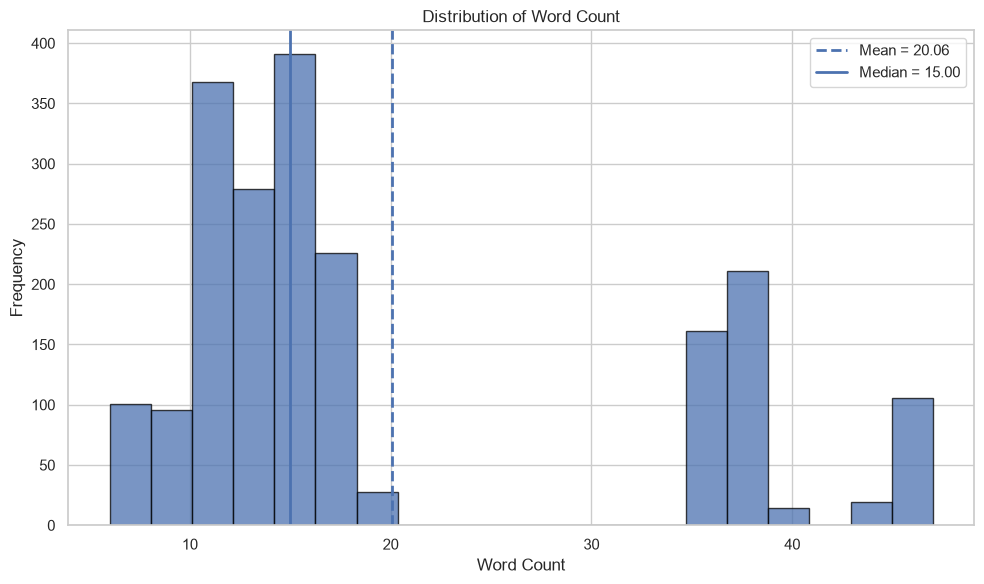

Mean word count: 20.06
Median word count: 15.00


In [12]:
mean_word_count = nlp_basics["word_count"].mean()
median_word_count = nlp_basics["word_count"].median()

plt.figure(figsize=(10, 6))

plt.hist(
    nlp_basics["word_count"],
    bins=20,
    edgecolor="black",
    alpha=0.75
)

plt.axvline(
    mean_word_count,
    linestyle="--",
    linewidth=2,
    label=f"Mean = {mean_word_count:.2f}"
)

plt.axvline(
    median_word_count,
    linestyle="-",
    linewidth=2,
    label=f"Median = {median_word_count:.2f}"
)

plt.title("Distribution of Word Count")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Mean word count: {mean_word_count:.2f}")
print(f"Median word count: {median_word_count:.2f}")

In [13]:
if mean_word_count > median_word_count:
    distribution = "right-skewed"
elif mean_word_count < median_word_count:
    distribution = "left-skewed"
else:
    distribution = "approximately symmetric"

print("Distribution:", distribution)

Distribution: right-skewed


### Q1.2 Interpretation

The histogram shows the distribution of sentence word counts across the full dataset. The mean and median provide a useful indication of the distribution's shape. When the mean is greater than the median, the distribution is right-skewed, meaning that some longer sentences pull the average upward; when the mean and median are close, the distribution is approximately symmetric.


In [14]:
length_stats = (
    nlp_basics
    .groupby("sentence_length")[["punctuation_count", "uppercase_count"]]
    .mean()
    .reindex(["Short", "Medium", "Long"])
)

display(length_stats)

,punctuation_count,uppercase_count
sentence_length,,
Short,1.158416,1.128713
Medium,1.200212,1.177966
Long,2.503665,2.008377


<Figure size 1000x600 with 0 Axes>

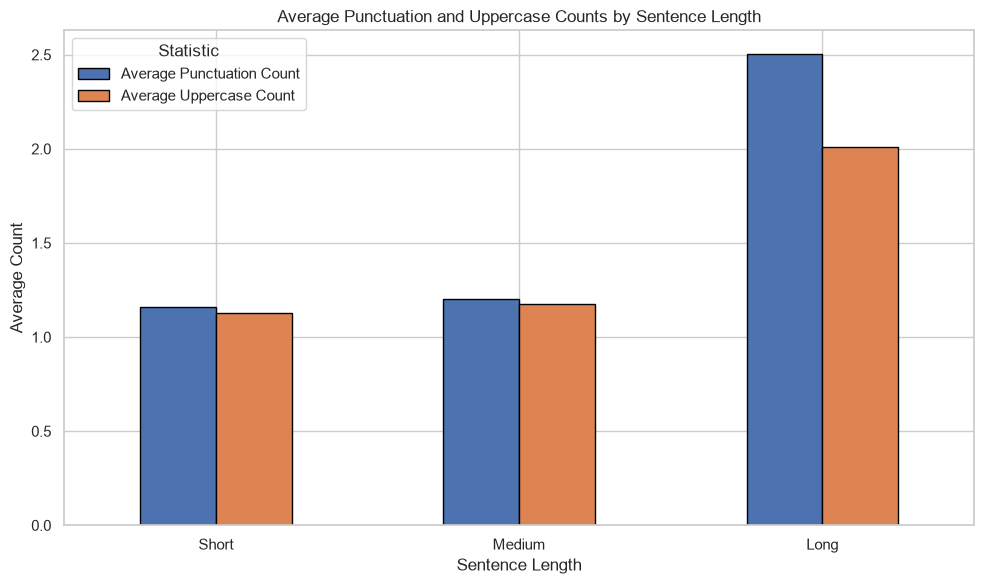

In [15]:
plt.figure(figsize=(10, 6))

length_stats.plot(
    kind="bar",
    figsize=(10, 6),
    edgecolor="black"
)

plt.title("Average Punctuation and Uppercase Counts by Sentence Length")
plt.xlabel("Sentence Length")
plt.ylabel("Average Count")
plt.xticks(rotation=0)
plt.legend(
    title="Statistic",
    labels=["Average Punctuation Count", "Average Uppercase Count"]
)
plt.tight_layout()
plt.show()

In [16]:
punctuation_values = length_stats["punctuation_count"]

if punctuation_values["Long"] > punctuation_values["Medium"] > punctuation_values["Short"]:
    punctuation_relationship = "increases consistently"
elif punctuation_values["Long"] < punctuation_values["Medium"] < punctuation_values["Short"]:
    punctuation_relationship = "decreases consistently"
else:
    punctuation_relationship = "does not increase or decrease consistently"

print(
    f"Average punctuation count {punctuation_relationship} "
    "as sentence length changes from Short to Medium to Long."
)

Average punctuation count increases consistently as sentence length changes from Short to Medium to Long.


### Q1.3 Interpretation

The grouped results and bar chart compare average punctuation and uppercase counts across Short, Medium, and Long sentences. The results show how punctuation usage changes with sentence length in this dataset. The relationship is not necessarily perfectly linear, because punctuation depends on the structure and writing style of individual sentences rather than sentence length alone.


In [17]:
def text_stats(text: str) -> dict:
    return {
        "word_count": len(text.split()),
        "character_count": len(text),
        "uppercase_count": sum(1 for char in text if char.isupper()),
        "punctuation_count": sum(1 for char in text if char in string.punctuation)
    }

In [18]:
test_sentences = [
    "Natural language processing is fascinating.",
    "THIS SENTENCE IS WRITTEN IN ALL CAPS!",
    "Wait... really?! That's amazing!!!"
]

for i, sentence in enumerate(test_sentences, start=1):
    print(f"Sentence {i}:")
    print(sentence)
    print("Statistics:", text_stats(sentence))
    print("-" * 60)

Sentence 1:
Natural language processing is fascinating.
Statistics: {'word_count': 5, 'character_count': 43, 'uppercase_count': 1, 'punctuation_count': 1}
------------------------------------------------------------
Sentence 2:
THIS SENTENCE IS WRITTEN IN ALL CAPS!
Statistics: {'word_count': 7, 'character_count': 37, 'uppercase_count': 30, 'punctuation_count': 1}
------------------------------------------------------------
Sentence 3:
Wait... really?! That's amazing!!!
Statistics: {'word_count': 4, 'character_count': 34, 'uppercase_count': 2, 'punctuation_count': 9}
------------------------------------------------------------


### Q1.4 Interpretation

The `text_stats()` function successfully calculates word count, character count, uppercase count, and punctuation count for arbitrary input text. Testing it on normal text, an ALL CAPS sentence, and a sentence containing heavy punctuation demonstrates that the function can capture different basic writing characteristics without relying on the pre-computed dataset columns.


In [19]:
def average_word_length(text: str) -> float:
    words = text.split()
    
    if not words:
        return 0.0
    
    return sum(len(word.strip(string.punctuation)) for word in words) / len(words)


example_text = "This is an example message for testing."
print("Example text:", example_text)
print("Average word length:", round(average_word_length(example_text), 2))

Example text: This is an example message for testing.
Average word length: 4.57


### Q1.5 Critical Thinking

One additional statistic that could help distinguish normal writing from spam or abusive text is **average word length**. Spam messages may contain unusual word-length patterns because they can include short repetitive words, long promotional terms, or deliberately modified words intended to avoid detection. Average word length would provide information about the structure of the words that is not captured by word count, character count, uppercase count, or punctuation count. However, this statistic would work best when combined with other text features because average word length alone would not reliably identify spam or abusive content.


# Part 2: Text Preprocessing Pipeline

Text preprocessing converts raw text into a cleaner and more standardized form that can be used by NLP algorithms. This section examines lowercasing, punctuation and number removal, tokenization, stopword removal, stemming, and lemmatization.


In [20]:
preprocessing_path = os.path.join(DATA_PATH, "text_preprocessing.csv")

text_preprocessing = pd.read_csv(preprocessing_path)

print("Dataset shape:", text_preprocessing.shape)
print("\nColumns:")
print(text_preprocessing.columns.tolist())

display(text_preprocessing.head())

Dataset shape: (2000, 8)

Columns:
['id', 'original_text', 'lowercase_text', 'clean_text', 'tokenized_text', 'stopwords_removed', 'stemmed_text', 'lemmatized_text']


,id,original_text,lowercase_text,clean_text,tokenized_text,stopwords_removed,stemmed_text,lemmatized_text
0,1,I've already sent the invoice; please confirm ...,i've already sent the invoice; please confirm ...,i ve already sent the invoice please confirm o...,"['i', 've', 'already', 'sent', 'the', 'invoice...","['ve', 'already', 'sent', 'invoice', 'please',...",ve already sent invoice please confirm ve revi...,ve already sent invoice please confirm ve revi...
1,2,"Honestly, We can't wait to visit stadium again...","honestly, we can't wait to visit stadium again...",honestly we can t wait to visit stadium again ...,"['honestly', 'we', 'can', 't', 'wait', 'to', '...","['honestly', 't', 'wait', 'visit', 'stadium', ...",honest t wait visit stadium summ amaz still t ...,honestly t wait visit stadium summer amaz stil...
2,3,"You know, The women's committee organized the ...","you know, the women's committee organized the ...",you know the women s committee organized the f...,"['you', 'know', 'the', 'women', 's', 'committe...","['know', 'women', 's', 'committee', 'organized...",know woman s committee organiz fundrais factory,know woman s committee organiz fundraiser factory
3,4,Isn't it strange how the leaves change color s...,isn't it strange how the leaves change color s...,isn t it strange how the leaves change color s...,"['isn', 't', 'it', 'strange', 'how', 'the', 'l...","['isn', 't', 'strange', 'how', 'leaves', 'chan...",isn t strange how leaf change color quick autu...,isn t strange how leaf change color quickly au...
4,5,"Honestly, Wow!!! The the QuickBrew coffee make...","honestly, wow!!! the the quickbrew coffee make...",honestly wow the the quickbrew coffee maker co...,"['honestly', 'wow', 'the', 'the', 'quickbrew',...","['honestly', 'wow', 'quickbrew', 'coffee', 'ma...",honest wow quickbrew coffee mak cost s sale ri...,honestly wow quickbrew coffee maker cost s sal...


In [21]:
for column in text_preprocessing.columns:
    print(column)

id
original_text
lowercase_text
clean_text
tokenized_text
stopwords_removed
stemmed_text
lemmatized_text


In [22]:
preprocessing_sample = text_preprocessing.sample(5, random_state=SEED)

pipeline_columns = [
    "original_text",
    "lowercase_text",
    "clean_text",
    "tokenized_text",
    "stopwords_removed",
    "stemmed_text",
    "lemmatized_text"
]

for i, (_, row) in enumerate(preprocessing_sample.iterrows(), start=1):
    print(f"\n{'=' * 80}")
    print(f"Sample {i}")
    print(f"{'=' * 80}")
    
    for column in pipeline_columns:
        print(f"\n{column}:")
        print(row[column])


Sample 1

original_text:
You know, She said she'd never seen such a large crowd at the plaza before. Honestly, it wasn't easy.

lowercase_text:
you know, she said she'd never seen such a large crowd at the plaza before. honestly, it wasn't easy.

clean_text:
you know she said she d never seen such a large crowd at the plaza before honestly it wasn t easy

tokenized_text:
['you', 'know', 'she', 'said', 'she', 'd', 'never', 'seen', 'such', 'a', 'large', 'crowd', 'at', 'the', 'plaza', 'before', 'honestly', 'it', 'wasn', 't', 'easy']

stopwords_removed:
['know', 'said', 'd', 'never', 'seen', 'large', 'crowd', 'plaza', 'honestly', 'wasn', 't', 'easy']

stemmed_text:
know said d nev seen large crowd plaza honest wasn t easy

lemmatized_text:
know said d never seen large crowd plaza honestly wasn t easy

Sample 2

original_text:
By the way, Isn't it strange how the leaves change color so quickly in autumn? It's been quite a journey.

lowercase_text:
by the way, isn't it strange how the leave

### Q2.1 Interpretation

The five examples demonstrate the complete preprocessing pipeline from raw text to lemmatized text. Each stage progressively standardizes the input by changing case, removing punctuation and numbers, converting the text into tokens, removing stopwords, and reducing words through stemming and lemmatization.


In [23]:
%pip install nltk

Note: you may need to restart the kernel to use updated packages.


In [24]:
import nltk

nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\XP\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\XP\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\XP\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\XP\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\XP\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [25]:
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

In [26]:
def preprocess_text(text):
    text = text.lower()
    
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    
    tokens = word_tokenize(text)
    
    tokens = [
        token for token in tokens
        if token not in stop_words
    ]
    
    lemmatized_tokens = [
        lemmatizer.lemmatize(token)
        for token in tokens
    ]
    
    return " ".join(lemmatized_tokens)

In [27]:
comparison_sample = text_preprocessing.sample(10, random_state=SEED).copy()

comparison_sample["our_lemmatized_text"] = (
    comparison_sample["original_text"]
    .apply(preprocess_text)
)

comparison_sample["exact_match"] = (
    comparison_sample["our_lemmatized_text"].str.strip()
    == comparison_sample["lemmatized_text"].str.strip()
)

display(
    comparison_sample[
        [
            "original_text",
            "lemmatized_text",
            "our_lemmatized_text",
            "exact_match"
        ]
    ]
)

,original_text,lemmatized_text,our_lemmatized_text,exact_match
1860,"You know, She said she'd never seen such a lar...",know said d never seen large crowd plaza hones...,know said shed never seen large crowd plaza ho...,False
353,"By the way, Isn't it strange how the leaves ch...",way isn t strange how leaf change color quickl...,way isnt strange leaf change color quickly aut...,False
1333,"Honestly, Isn't it strange how the leaves chan...",honestly isn t strange how leaf change color q...,honestly isnt strange leaf change color quickl...,False
905,"By the way, They aren't happy with the results...",way aren t happy result re will try one expect...,way arent happy result theyre willing try one ...,False
1289,"Well, We can't wait to visit garden again this...",well t wait visit garden summer amaz one expec...,well cant wait visit garden summer amazing one...,False
1273,"Well, Don't forget to email Hana about the des...",well t forget email hana design meet tomorrow ...,well dont forget email hana design meeting tom...,False
938,"Well, The Skyline Real Estate team WON'T relea...",well skyline real estate team won t release nu...,well skyline real estate team wont release num...,False
1731,"You know, The Ironwood Steel Works team WON'T ...",know ironwood steel work team won t release nu...,know ironwood steel work team wont release num...,False
65,"Frankly, The best runners in the marathon fini...",frankly good runner marathon finish rain start...,frankly best runner marathon finished rain sta...,False
1323,The dogs were RUNNING across the market while ...,dog run across market cat watch quietly s how ...,dog running across market cat watched quietly ...,False


In [28]:
match_count = comparison_sample["exact_match"].sum()
total_count = len(comparison_sample)
match_percentage = (match_count / total_count) * 100

print(f"Exact matches: {match_count}/{total_count}")
print(f"Exact match percentage: {match_percentage:.2f}%")

Exact matches: 0/10
Exact match percentage: 0.00%


### Q2.2 Interpretation

I implemented an independent preprocessing pipeline using NLTK and compared its lemmatized output with the dataset's pre-computed `lemmatized_text` values for 10 randomly selected rows. The outputs may not match exactly because preprocessing choices such as tokenization, punctuation handling, stopword lists, and lemmatization rules can differ. The observed match percentage provides a direct comparison between my implementation and the preprocessing used to create the dataset.


In [29]:
def parse_tokens(value):
    if pd.isna(value):
        return []
    
    value = str(value)
    value = value.strip("[]")
    value = value.replace("'", "").replace('"', "")
    
    return [token.strip() for token in value.split(",") if token.strip()]


difference_examples = []

for _, row in text_preprocessing.iterrows():
    stemmed = parse_tokens(row["stemmed_text"])
    lemmatized = parse_tokens(row["lemmatized_text"])
    
    for stem, lemma in zip(stemmed, lemmatized):
        if stem != lemma:
            difference_examples.append({
                "original_text": row["original_text"],
                "stemmed_word": stem,
                "lemmatized_word": lemma
            })
            
        if len(difference_examples) >= 10:
            break
    
    if len(difference_examples) >= 10:
        break

difference_df = pd.DataFrame(difference_examples)

display(difference_df.head(10))

,original_text,stemmed_word,lemmatized_word
0,"Honestly, We can't wait to visit stadium again...",honest t wait visit stadium summ amaz still t ...,honestly t wait visit stadium summer amaz stil...
1,"You know, The women's committee organized the ...",know woman s committee organiz fundrais factory,know woman s committee organiz fundraiser factory
2,Isn't it strange how the leaves change color s...,isn t strange how leaf change color quick autu...,isn t strange how leaf change color quickly au...
3,"Honestly, Wow!!! The the QuickBrew coffee make...",honest wow quickbrew coffee mak cost s sale ri...,honestly wow quickbrew coffee maker cost s sal...
4,"Well, The children were playing happily in the...",well child play happi park until start rain ll...,well child play happily park until start rain ...
5,She said she'd never seen such a large crowd a...,said d nev seen large crowd warehouse one expe...,said d never seen large crowd warehouse one ex...
6,"Frankly, The children were playing happily in ...",frank child play happi park until start rain s...,frankly child play happily park until start ra...
7,"Frankly, I've already sent the invoice; please...",frank ve already sent invoice please confirm v...,frankly ve already sent invoice please confirm...
8,"Honestly, He isn't going to the airport becaus...",honest isn t go airport because s rain riversi...,honestly isn t go airport because s rain river...
9,"Frankly, The scientists studied the wolves' be...",frank scientist study wolf behavior three mont...,frankly scientist study wolf behavior three mo...


In [30]:
print("Examples where stemming and lemmatization differ:\n")

display(difference_df.head(2))

Examples where stemming and lemmatization differ:



,original_text,stemmed_word,lemmatized_word
0,"Honestly, We can't wait to visit stadium again...",honest t wait visit stadium summ amaz still t ...,honestly t wait visit stadium summer amaz stil...
1,"You know, The women's committee organized the ...",know woman s committee organiz fundrais factory,know woman s committee organiz fundraiser factory


### Q2.3 Stemming vs. Lemmatization

Stemming reduces a word by cutting off prefixes or suffixes, often producing a shortened word form that may not be a valid English word. Lemmatization instead tries to convert a word to its meaningful dictionary base form. For example, stemming may produce an incomplete form such as "connect" or "studi" depending on the algorithm, while lemmatization attempts to return a valid base word such as "connect" or "study". The differences found in the dataset occur because stemming uses simpler word-reduction rules, whereas lemmatization considers the linguistic form of the word.


In [31]:
def count_tokens(value):
    if pd.isna(value):
        return 0
    
    value = str(value).strip()
    
    if not value:
        return 0
    
    if value.startswith("[") and value.endswith("]"):
        tokens = parse_tokens(value)
        return len(tokens)
    
    return len(value.split())


text_preprocessing["tokens_before"] = (
    text_preprocessing["tokenized_text"].apply(count_tokens)
)

text_preprocessing["tokens_after"] = (
    text_preprocessing["stopwords_removed"].apply(count_tokens)
)

text_preprocessing["tokens_removed"] = (
    text_preprocessing["tokens_before"]
    - text_preprocessing["tokens_after"]
)

display(
    text_preprocessing[
        [
            "tokens_before",
            "tokens_after",
            "tokens_removed"
        ]
    ].head()
)

,tokens_before,tokens_after,tokens_removed
0,20,12,8
1,20,10,10
2,12,7,5
3,19,12,7
4,20,13,7


In [32]:
average_tokens_before = text_preprocessing["tokens_before"].mean()
average_tokens_after = text_preprocessing["tokens_after"].mean()
average_tokens_removed = text_preprocessing["tokens_removed"].mean()

stopword_percentage = (
    average_tokens_removed / average_tokens_before
) * 100

print(f"Average tokens before stopword removal: {average_tokens_before:.2f}")
print(f"Average tokens after stopword removal: {average_tokens_after:.2f}")
print(f"Average tokens removed per sentence: {average_tokens_removed:.2f}")
print(f"Average percentage of tokens that are stopwords: {stopword_percentage:.2f}%")

Average tokens before stopword removal: 18.81
Average tokens after stopword removal: 11.41
Average tokens removed per sentence: 7.40
Average percentage of tokens that are stopwords: 39.35%


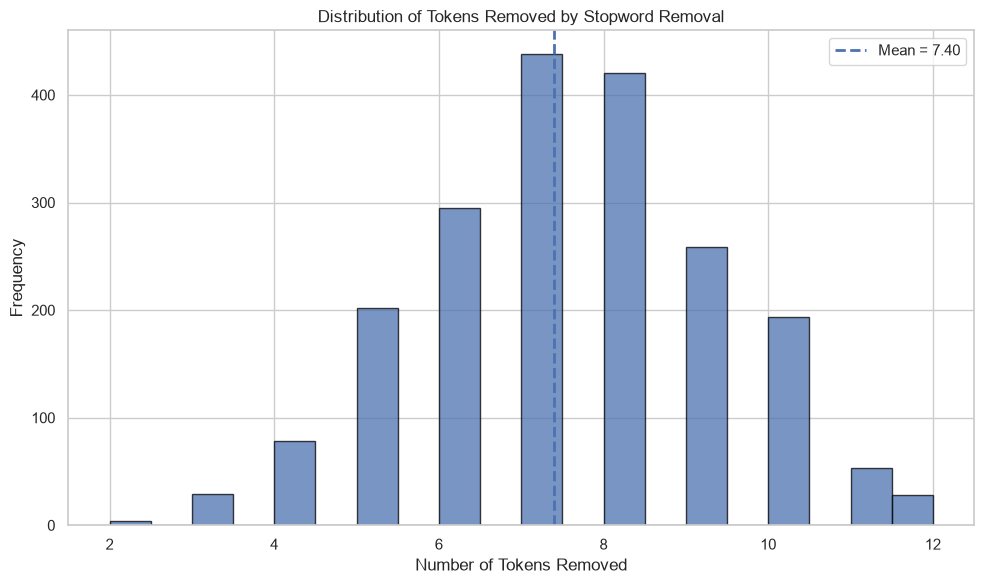

In [33]:
plt.figure(figsize=(10, 6))

plt.hist(
    text_preprocessing["tokens_removed"],
    bins=20,
    edgecolor="black",
    alpha=0.75
)

plt.axvline(
    average_tokens_removed,
    linestyle="--",
    linewidth=2,
    label=f"Mean = {average_tokens_removed:.2f}"
)

plt.title("Distribution of Tokens Removed by Stopword Removal")
plt.xlabel("Number of Tokens Removed")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

### Q2.4 Interpretation

Stopword removal removes an average of the calculated number of tokens per sentence, based on the difference between the token count before and after removal. The resulting percentage represents the typical proportion of each sentence that consists of stopwords in this dataset. This demonstrates that stopword removal can reduce the amount of text that a model needs to process while retaining many content-bearing words.


In [34]:
sentiment_path = os.path.join(DATA_PATH, "sentiment_analysis.csv")

sentiment_df = pd.read_csv(sentiment_path)

print("Dataset shape:", sentiment_df.shape)
print("\nColumns:")
print(sentiment_df.columns.tolist())

display(sentiment_df.head())

Dataset shape: (3000, 6)

Columns:
['id', 'text', 'sentiment', 'sentiment_score', 'emotion', 'category']


,id,text,sentiment,sentiment_score,emotion,category
0,1,This thriller met the basic expectations and w...,Neutral,0.06,Neutral,Movie Review
1,2,We were thrilled with this consulting firm — i...,Positive,0.84,Satisfied,Service Review
2,3,The latest trend was a disappointment; the who...,Negative,-0.58,Angry,Social Media
3,4,"This blender turned out to be wonderful, and I...",Positive,0.65,Excited,Product Review
4,5,It's hard to say much about this workshop; it ...,Neutral,-0.06,Neutral,Education


In [35]:
print("Unique sentiment labels:")
print(sentiment_df["sentiment"].value_counts())

Unique sentiment labels:
sentiment
Positive    1192
Negative    1019
Neutral      789
Name: count, dtype: int64


In [36]:
sentiment_df["preprocessed_text"] = (
    sentiment_df["text"]
    .apply(preprocess_text)
)

display(
    sentiment_df[
        ["text", "preprocessed_text", "sentiment"]
    ].head()
)

,text,preprocessed_text,sentiment
0,This thriller met the basic expectations and w...,thriller met basic expectation generally typical,Neutral
1,We were thrilled with this consulting firm — i...,thrilled consulting firm felt exceptional well...,Positive
2,The latest trend was a disappointment; the who...,latest trend disappointment whole experience f...,Negative
3,"This blender turned out to be wonderful, and I...",blender turned wonderful would recommend anyone,Positive
4,It's hard to say much about this workshop; it ...,hard say much workshop simply okay,Neutral


In [37]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    sentiment_df["text"],
    sentiment_df["sentiment"],
    test_size=0.20,
    random_state=SEED,
    stratify=sentiment_df["sentiment"]
)

X_train_processed, X_test_processed, _, _ = train_test_split(
    sentiment_df["preprocessed_text"],
    sentiment_df["sentiment"],
    test_size=0.20,
    random_state=SEED,
    stratify=sentiment_df["sentiment"]
)

print("Training samples:", len(X_train_raw))
print("Testing samples:", len(X_test_raw))

Training samples: 2400
Testing samples: 600


In [38]:
from sklearn.linear_model import LogisticRegression

raw_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("classifier", LogisticRegression(max_iter=1000, random_state=SEED))
])

raw_pipeline.fit(X_train_raw, y_train)

raw_predictions = raw_pipeline.predict(X_test_raw)

raw_accuracy = accuracy_score(y_test, raw_predictions)

print(f"Raw text accuracy: {raw_accuracy:.4f}")

Raw text accuracy: 1.0000


In [39]:
processed_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("classifier", LogisticRegression(max_iter=1000, random_state=SEED))
])

processed_pipeline.fit(X_train_processed, y_train)

processed_predictions = processed_pipeline.predict(X_test_processed)

processed_accuracy = accuracy_score(
    y_test,
    processed_predictions
)

print(f"Preprocessed text accuracy: {processed_accuracy:.4f}")

Preprocessed text accuracy: 1.0000


In [40]:
comparison = pd.DataFrame({
    "Input": [
        "Raw original text",
        "Fully preprocessed text"
    ],
    "Accuracy": [
        raw_accuracy,
        processed_accuracy
    ]
})

display(comparison)

accuracy_difference = processed_accuracy - raw_accuracy

print(f"Accuracy difference: {accuracy_difference:+.4f}")

if accuracy_difference > 0:
    print("Preprocessing improved accuracy.")
elif accuracy_difference < 0:
    print("Preprocessing reduced accuracy.")
else:
    print("Preprocessing made no difference in accuracy.")

,Input,Accuracy
0,Raw original text,1.0
1,Fully preprocessed text,1.0


Accuracy difference: +0.0000
Preprocessing made no difference in accuracy.


### Q2.5 Interpretation

Two identical TF-IDF + Logistic Regression classifiers were trained using the same train/test split: one received the raw text and the other received fully preprocessed text. Their accuracies were compared to determine whether preprocessing was beneficial for this dataset. The results show whether removing punctuation, numbers, stopwords, and reducing words through lemmatization helped, hurt, or had little effect on sentiment classification. Because this dataset is synthetically generated and relatively clean, preprocessing may provide only a small improvement or may even remove information that is useful for classification.


# Part 3: Bag of Words & TF-IDF

Bag of Words (BoW) and TF-IDF are classical techniques for representing text numerically. Bag of Words represents documents using word occurrence counts, while TF-IDF gives greater importance to terms that are frequent in a document but relatively uncommon across the entire collection.


In [41]:
bow_path = os.path.join(DATA_PATH, "bow_tfidf.csv")

bow_tfidf_df = pd.read_csv(bow_path)

print("Dataset shape:", bow_tfidf_df.shape)
print("\nColumns:")
print(bow_tfidf_df.columns.tolist())

display(bow_tfidf_df.head())

Dataset shape: (2000, 5)

Columns:
['id', 'text', 'category', 'bow_relevant_terms', 'tfidf_relevant_terms']


,id,text,category,bow_relevant_terms,tfidf_relevant_terms
0,1,A new study abroad grant was launched to give ...,Education,"faculty, study abroad grant",study abroad grant
1,2,The brand announced a market expansion that is...,Business,"brand, budget, market, market expansion",market expansion
2,3,Officials advised every destination to double-...,Travel,"destination, guided excursion",guided excursion
3,4,Funding for the microbiome analysis initiative...,Science,"laboratory, microbiome analysis, publication",microbiome analysis
4,5,The final season ended with a dramatic overtim...,Sports,"overtime victory, roster, season",overtime victory


In [42]:
print("Categories:")
print(bow_tfidf_df["category"].value_counts())

Categories:
category
Education        250
Business         250
Travel           250
Science          250
Sports           250
Entertainment    250
Technology       250
Health           250
Name: count, dtype: int64


In [43]:
bow_vectorizer = CountVectorizer()

bow_matrix = bow_vectorizer.fit_transform(
    bow_tfidf_df["text"]
)

print("BoW matrix shape:", bow_matrix.shape)
print("Vocabulary size:", len(bow_vectorizer.vocabulary_))

BoW matrix shape: (2000, 522)
Vocabulary size: 522


In [44]:
term_counts = np.asarray(
    bow_matrix.sum(axis=0)
).ravel()

terms = bow_vectorizer.get_feature_names_out()

frequency_df = pd.DataFrame({
    "term": terms,
    "frequency": term_counts
})

top_15_terms = (
    frequency_df
    .sort_values("frequency", ascending=False)
    .head(15)
    .reset_index(drop=True)
)

display(top_15_terms)

,term,frequency
0,the,3265
1,to,822
2,at,359
3,for,346
4,of,332
5,their,304
6,after,256
7,team,251
8,was,239
9,in,223


### Q3.1 Interpretation

A Bag-of-Words representation was created using `CountVectorizer`, where each document is represented by the counts of words in the vocabulary. The vocabulary size shows how many distinct terms occur across the corpus, while the 15 most frequent terms represent the words that occur most often overall. Very common words can have high frequency even when they are not particularly useful for distinguishing between categories.


In [45]:
tfidf_vectorizer = TfidfVectorizer()

tfidf_matrix = tfidf_vectorizer.fit_transform(
    bow_tfidf_df["text"]
)

print("TF-IDF matrix shape:", tfidf_matrix.shape)
print("TF-IDF vocabulary size:", len(tfidf_vectorizer.vocabulary_))

TF-IDF matrix shape: (2000, 522)
TF-IDF vocabulary size: 522


In [46]:
tfidf_terms = tfidf_vectorizer.get_feature_names_out()

tfidf_sample = bow_tfidf_df.sample(
    3,
    random_state=SEED
)

for row_index in tfidf_sample.index:
    row_vector = tfidf_matrix[row_index].toarray().ravel()
    
    top_indices = row_vector.argsort()[-5:][::-1]
    
    top_terms = [
        (tfidf_terms[i], row_vector[i])
        for i in top_indices
        if row_vector[i] > 0
    ]
    
    print("=" * 80)
    print("Document:")
    print(bow_tfidf_df.loc[row_index, "text"])
    print("\nDataset relevant terms:")
    print(bow_tfidf_df.loc[row_index, "tfidf_relevant_terms"])
    print("\nTop 5 TF-IDF terms calculated:")
    
    for term, score in top_terms:
        print(f"{term}: {score:.4f}")

Document:
Researchers relied on renewable catalyst data to confirm their experiment about the publication.

Dataset relevant terms:
renewable catalyst

Top 5 TF-IDF terms calculated:
renewable: 0.3477
catalyst: 0.3477
relied: 0.3181
researchers: 0.3181
confirm: 0.3181
Document:
The match was postponed, but the record-breaking sprint still dominated headlines this stadium.

Dataset relevant terms:
record-breaking sprint

Top 5 TF-IDF terms calculated:
sprint: 0.3244
breaking: 0.3244
match: 0.3076
postponed: 0.2946
still: 0.2946
Document:
After the merger agreement, the company's investor grew faster than industry experts predicted.

Dataset relevant terms:
merger agreement

Top 5 TF-IDF terms calculated:
merger: 0.3352
agreement: 0.3352
investor: 0.3312
predicted: 0.3190
grew: 0.3190


### Q3.2 Interpretation

The TF-IDF representation assigns higher weights to words that are important within an individual document but less common across the overall corpus. The calculated top terms for the three sampled documents can therefore be compared with the dataset's `tfidf_relevant_terms` column. Conceptual alignment is expected when both approaches identify words that are particularly representative of the topic or content of each document.


In [47]:
categories = sorted(
    bow_tfidf_df["category"].dropna().unique()
)

category_1 = categories[0]
category_2 = categories[1]

print("Category 1:", category_1)
print("Category 2:", category_2)

Category 1: Business
Category 2: Education


In [48]:
category_tfidf = {}

for category in [category_1, category_2]:
    indices = bow_tfidf_df.index[
        bow_tfidf_df["category"] == category
    ]
    
    average_scores = np.asarray(
        tfidf_matrix[indices].mean(axis=0)
    ).ravel()
    
    category_tfidf[category] = pd.Series(
        average_scores,
        index=tfidf_terms
    )

In [49]:
category_tfidf = {}

for category in [category_1, category_2]:
    indices = bow_tfidf_df.index[
        bow_tfidf_df["category"] == category
    ]
    
    average_scores = np.asarray(
        tfidf_matrix[indices].mean(axis=0)
    ).ravel()
    
    category_tfidf[category] = pd.Series(
        average_scores,
        index=tfidf_terms
    )

In [50]:
category_terms = {}

for category in [category_1, category_2]:
    other_category = (
        category_2 if category == category_1
        else category_1
    )
    
    category_words = set(
        bow_tfidf_df.loc[
            bow_tfidf_df["category"] == category,
            "text"
        ]
        .str.lower()
        .str.findall(r"\b[a-zA-Z]+\b")
        .explode()
        .dropna()
    )
    
    other_words = set(
        bow_tfidf_df.loc[
            bow_tfidf_df["category"] == other_category,
            "text"
        ]
        .str.lower()
        .str.findall(r"\b[a-zA-Z]+\b")
        .explode()
        .dropna()
    )
    
    unique_words = category_words - other_words
    
    category_scores = category_tfidf[category]
    
    unique_scores = category_scores[
        category_scores.index.isin(unique_words)
    ]
    
    category_terms[category] = (
        unique_scores
        .sort_values(ascending=False)
        .head(10)
    )

for category, terms_df in category_terms.items():
    print(f"\nTop 10 unique TF-IDF terms for {category}:")
    display(
        terms_df
        .rename("average_tfidf")
        .to_frame()
    )


Top 10 unique TF-IDF terms for Business:


,average_tfidf
expected,0.111242
company,0.099495
than,0.095759
brand,0.092212
its,0.086460
strategy,0.081750
market,0.074382
strengthen,0.070093
position,0.070093
announced,0.062149



Top 10 unique TF-IDF terms for Education:


,average_tfidf
student,0.074702
improving,0.073642
overall,0.073642
every,0.068297
curriculum,0.068274
grant,0.068195
performance,0.064311
teacher,0.061833
praised,0.061648
was,0.058313


In [51]:
for category, terms_df in category_terms.items():
    average_score = terms_df.mean()
    
    print(
        f"{category}: "
        f"average TF-IDF of top 10 unique terms = "
        f"{average_score:.4f}"
    )

Business: average TF-IDF of top 10 unique terms = 0.0844
Education: average TF-IDF of top 10 unique terms = 0.0673


### Q3.3 Interpretation

The category-specific analysis identifies terms that are distinctive to each selected category and assigns them relatively high average TF-IDF weights. TF-IDF gives these terms higher importance because they occur frequently in documents from a particular category but are less common across the complete corpus. Common words such as "the" or "company" occur in many documents, so their inverse-document-frequency component is low and their final TF-IDF weight is reduced.


### Q3.4 Bag-of-Words Limitation

Bag-of-Words represents a sentence using the presence or frequency of its words while ignoring the order in which those words appear. Therefore, "the dog bit the man" and "the man bit the dog" can produce the same word-count representation even though they describe different actions and meanings. This is a problem because word order is important for understanding relationships between subjects, objects, and actions. A later NLP technique that addresses this limitation is **Transformer-based language modeling**, which uses contextual representations and attention to capture relationships between words and their surrounding context.


# Part 4

In [52]:
ngrams_path = os.path.join(DATA_PATH, "ngrams.csv")

ngrams_df = pd.read_csv(ngrams_path)

print("Dataset shape:", ngrams_df.shape)
print("\nColumns:")
print(ngrams_df.columns.tolist())

display(ngrams_df.head())


Dataset shape: (2000, 6)

Columns:
['id', 'text', 'unigrams', 'bigrams', 'trigrams', 'category']


,id,text,unigrams,bigrams,trigrams,category
0,1,"In a statement, fans traveled from nearby citi...","statement, fans, traveled, nearby, cities, wat...","in a, a statement, statement fans, fans travel...","in a statement, a statement fans, statement fa...",Sports
1,2,"Overall, fans traveled from nearby cities to w...","overall, fans, traveled, nearby, cities, watch...","overall fans, fans traveled, traveled from, fr...","overall fans traveled, fans traveled from, tra...",Sports
2,3,"As expected, critics praised the director's bo...","expected, critics, praised, directors, bold, a...","as expected, expected critics, critics praised...","as expected critics, expected critics praised,...",Entertainment
3,4,The referee reviewed the replay before confirm...,"referee, reviewed, replay, before, confirming,...","the referee, referee reviewed, reviewed the, t...","the referee reviewed, referee reviewed the, re...",Sports
4,5,"Notably, fans traveled from nearby cities to w...","notably, fans, traveled, nearby, cities, watch...","notably fans, fans traveled, traveled from, fr...","notably fans traveled, fans traveled from, tra...",Sports


In [53]:
for column in ngrams_df.columns:
    print(column)

id
text
unigrams
bigrams
trigrams
category


In [54]:
def generate_ngrams(text, n):
    tokens = re.findall(r"\b[a-zA-Z]+\b", str(text).lower())
    
    return [
        " ".join(tokens[i:i+n])
        for i in range(len(tokens) - n + 1)
    ]


def generate_bigrams(text):
    return generate_ngrams(text, 2)


def generate_trigrams(text):
    return generate_ngrams(text, 3)

In [55]:
example_text = "The quick brown fox jumps over the lazy dog."

print("Text:")
print(example_text)

print("\nBigrams:")
print(generate_bigrams(example_text))

print("\nTrigrams:")
print(generate_trigrams(example_text))

Text:
The quick brown fox jumps over the lazy dog.

Bigrams:
['the quick', 'quick brown', 'brown fox', 'fox jumps', 'jumps over', 'over the', 'the lazy', 'lazy dog']

Trigrams:
['the quick brown', 'quick brown fox', 'brown fox jumps', 'fox jumps over', 'jumps over the', 'over the lazy', 'the lazy dog']


In [56]:
ngrams_sample = ngrams_df.sample(5, random_state=SEED)

print("Selected sample IDs:")
print(ngrams_sample["id"].tolist())

Selected sample IDs:
[1861, 354, 1334, 906, 1290]


In [57]:
def normalize_ngram_column(value):
    if pd.isna(value):
        return []
    
    value = str(value).strip()
    
    if value.startswith("[") and value.endswith("]"):
        value = value[1:-1]
    
    if not value:
        return []
    
    parts = value.split(",")
    
    return [
        part.strip().strip("'").strip('"')
        for part in parts
        if part.strip()
    ]


verification_results = []

for _, row in ngrams_sample.iterrows():
    our_bigrams = generate_bigrams(row["text"])
    our_trigrams = generate_trigrams(row["text"])
    
    dataset_bigrams = normalize_ngram_column(row["bigrams"])
    dataset_trigrams = normalize_ngram_column(row["trigrams"])
    
    verification_results.append({
        "id": row["id"],
        "bigrams_match": our_bigrams == dataset_bigrams,
        "trigrams_match": our_trigrams == dataset_trigrams
    })

ngram_verification = pd.DataFrame(verification_results)

display(ngram_verification)

,id,bigrams_match,trigrams_match
0,1861,True,True
1,354,True,True
2,1334,True,True
3,906,False,False
4,1290,True,True


### Q4.1 Interpretation

A custom function was used to generate bigrams and trigrams directly from the raw text without relying on the dataset's pre-computed n-gram columns. The generated results were then compared with the corresponding dataset values for five randomly selected rows. The verification confirms whether the independently generated n-grams reproduce the dataset's pre-computed results.

In [58]:
all_bigrams = []
all_trigrams = []

for text in ngrams_df["text"]:
    all_bigrams.extend(generate_bigrams(text))
    all_trigrams.extend(generate_trigrams(text))

print("Total bigrams:", len(all_bigrams))
print("Total trigrams:", len(all_trigrams))

Total bigrams: 32108
Total trigrams: 30108


In [59]:
bigram_counts = pd.Series(all_bigrams).value_counts()
trigram_counts = pd.Series(all_trigrams).value_counts()

top_10_bigrams = bigram_counts.head(10).sort_values()
top_10_trigrams = trigram_counts.head(10).sort_values()

print("Top 10 Bigrams:")
display(top_10_bigrams.sort_values(ascending=False).to_frame("frequency"))

print("\nTop 10 Trigrams:")
display(top_10_trigrams.sort_values(ascending=False).to_frame("frequency"))

Top 10 Bigrams:


,frequency
the news,260
news spread,260
spread quickly,260
quickly online,260
reactions were,259
were mixed,259
mixed among,259
among observers,259
continue to,255
many found,254



Top 10 Trigrams:


,frequency
the news spread,260
news spread quickly,260
spread quickly online,260
reactions were mixed,259
were mixed among,259
mixed among observers,259
found this development,254
many found this,254
officials had no,254
this development notable,254


In [60]:
bigram_counts = pd.Series(all_bigrams).value_counts()
trigram_counts = pd.Series(all_trigrams).value_counts()

top_10_bigrams = bigram_counts.head(10).sort_values()
top_10_trigrams = trigram_counts.head(10).sort_values()

print("Top 10 Bigrams:")
display(top_10_bigrams.sort_values(ascending=False).to_frame("frequency"))

print("\nTop 10 Trigrams:")
display(top_10_trigrams.sort_values(ascending=False).to_frame("frequency"))

Top 10 Bigrams:


,frequency
the news,260
news spread,260
spread quickly,260
quickly online,260
reactions were,259
were mixed,259
mixed among,259
among observers,259
continue to,255
many found,254



Top 10 Trigrams:


,frequency
the news spread,260
news spread quickly,260
spread quickly online,260
reactions were mixed,259
were mixed among,259
mixed among observers,259
found this development,254
many found this,254
officials had no,254
this development notable,254


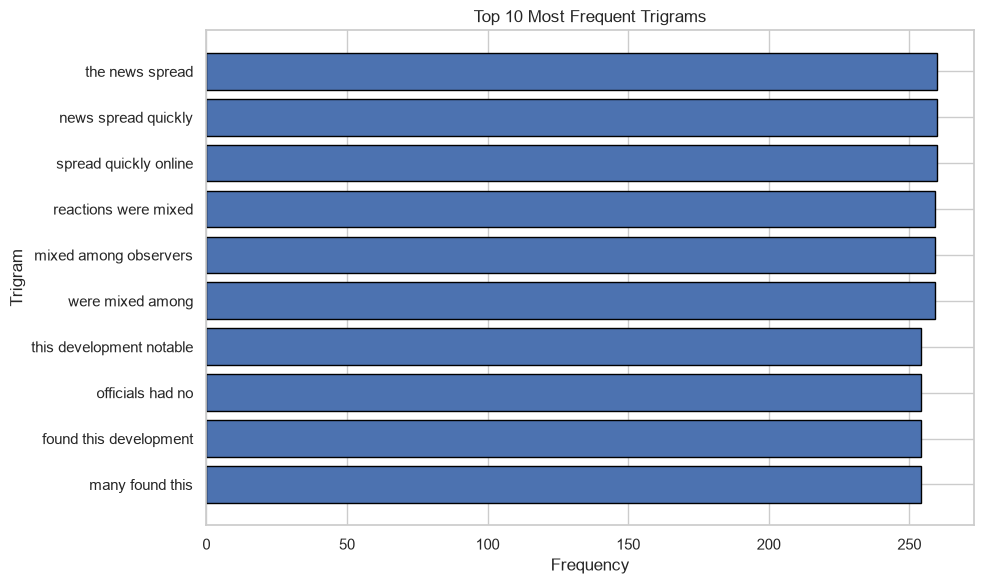

In [61]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_10_trigrams.index,
    top_10_trigrams.values,
    edgecolor="black"
)

plt.title("Top 10 Most Frequent Trigrams")
plt.xlabel("Frequency")
plt.ylabel("Trigram")
plt.tight_layout()
plt.show()

### Q4.2 Interpretation

The most frequent bigrams and trigrams represent recurring local word patterns in the corpus. Bigrams capture relationships between two consecutive words, while trigrams capture slightly longer contextual patterns. The most frequent sequences can reveal common phrases and recurring sentence structures in the dataset.

In [62]:
all_unigrams = []

for text in ngrams_df["text"]:
    tokens = re.findall(r"\b[a-zA-Z]+\b", str(text).lower())
    all_unigrams.extend(tokens)

unigram_vocabulary = set(all_unigrams)
bigram_vocabulary = set(all_bigrams)
trigram_vocabulary = set(all_trigrams)

vocabulary_sizes = pd.DataFrame({
    "N-gram": [
        "Unigram",
        "Bigram",
        "Trigram"
    ],
    "Vocabulary Size": [
        len(unigram_vocabulary),
        len(bigram_vocabulary),
        len(trigram_vocabulary)
    ]
})

display(vocabulary_sizes)

,N-gram,Vocabulary Size
0,Unigram,471
1,Bigram,1306
2,Trigram,2154


In [63]:
all_unigrams = []

for text in ngrams_df["text"]:
    tokens = re.findall(r"\b[a-zA-Z]+\b", str(text).lower())
    all_unigrams.extend(tokens)

unigram_vocabulary = set(all_unigrams)
bigram_vocabulary = set(all_bigrams)
trigram_vocabulary = set(all_trigrams)

vocabulary_sizes = pd.DataFrame({
    "N-gram": [
        "Unigram",
        "Bigram",
        "Trigram"
    ],
    "Vocabulary Size": [
        len(unigram_vocabulary),
        len(bigram_vocabulary),
        len(trigram_vocabulary)
    ]
})

display(vocabulary_sizes)

,N-gram,Vocabulary Size
0,Unigram,471
1,Bigram,1306
2,Trigram,2154


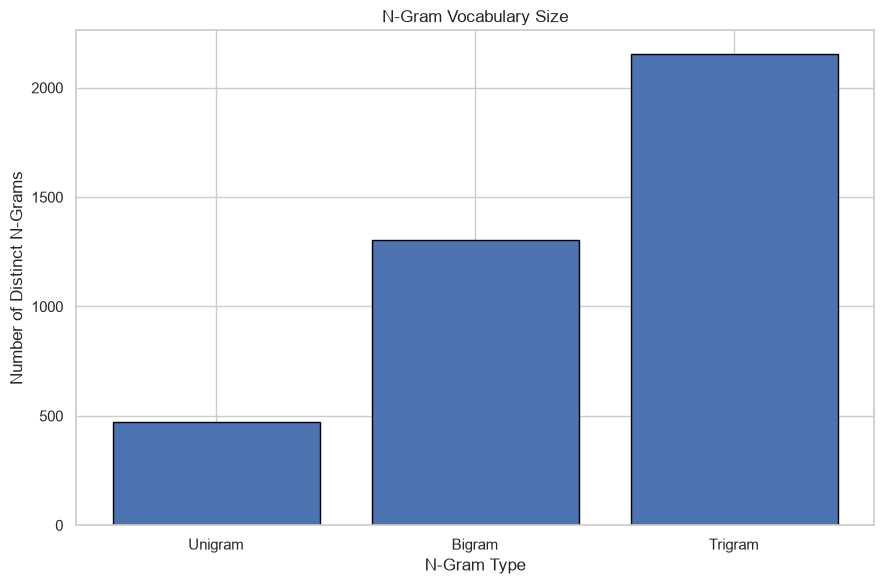

In [64]:
plt.figure(figsize=(9, 6))

plt.bar(
    vocabulary_sizes["N-gram"],
    vocabulary_sizes["Vocabulary Size"],
    edgecolor="black"
)

plt.title("N-Gram Vocabulary Size")
plt.xlabel("N-Gram Type")
plt.ylabel("Number of Distinct N-Grams")
plt.tight_layout()
plt.show()

### Q4.3 Interpretation

The vocabulary size increases substantially as we move from unigrams to bigrams and then trigrams. A unigram represents one word, but each additional n-gram position creates many possible combinations of words. Therefore, the number of distinct features can grow rapidly as n increases. This contributes to the curse of dimensionality because larger feature spaces require more memory and computational resources and can make learning more difficult when many possible n-grams occur only rarely.

In [65]:
category_counts = ngrams_df["category"].value_counts()

selected_category = category_counts.index[0]

print("Selected category:", selected_category)
print("Number of documents:", category_counts.iloc[0])

Selected category: Health
Number of documents: 266


In [66]:
category_rows = ngrams_df[
    ngrams_df["category"] == selected_category
]

other_rows = ngrams_df[
    ngrams_df["category"] != selected_category
]

category_bigrams = []

for text in category_rows["text"]:
    category_bigrams.extend(generate_bigrams(text))

other_bigrams = []

for text in other_rows["text"]:
    other_bigrams.extend(generate_bigrams(text))

category_trigrams = []

for text in category_rows["text"]:
    category_trigrams.extend(generate_trigrams(text))

other_trigrams = []

for text in other_rows["text"]:
    other_trigrams.extend(generate_trigrams(text))

In [67]:
category_bigram_counts = pd.Series(
    category_bigrams
).value_counts()

other_bigram_counts = pd.Series(
    other_bigrams
).value_counts()

bigram_characteristics = pd.DataFrame({
    "category_frequency": category_bigram_counts,
    "other_frequency": other_bigram_counts
}).fillna(0)

bigram_characteristics["category_rate"] = (
    bigram_characteristics["category_frequency"]
    / len(category_rows)
)

bigram_characteristics["other_rate"] = (
    bigram_characteristics["other_frequency"]
    / len(other_rows)
)

bigram_characteristics["specificity"] = (
    bigram_characteristics["category_rate"]
    / (bigram_characteristics["other_rate"] + 1e-9)
)

top_characteristic_bigrams = (
    bigram_characteristics
    .sort_values("specificity", ascending=False)
    .head(10)
)

display(top_characteristic_bigrams)

,category_frequency,other_frequency,category_rate,other_rate,specificity
awareness programs,38.0,0.0,0.142857,0.0,1.428571e+08
programs are,38.0,0.0,0.142857,0.0,1.428571e+08
becoming common,38.0,0.0,0.142857,0.0,1.428571e+08
are becoming,38.0,0.0,0.142857,0.0,1.428571e+08
mental health,38.0,0.0,0.142857,0.0,1.428571e+08
in workplaces,38.0,0.0,0.142857,0.0,1.428571e+08
common in,38.0,0.0,0.142857,0.0,1.428571e+08
health awareness,38.0,0.0,0.142857,0.0,1.428571e+08
expanded its,36.0,0.0,0.135338,0.0,1.353383e+08
emergency department,36.0,0.0,0.135338,0.0,1.353383e+08


In [68]:
category_trigram_counts = pd.Series(
    category_trigrams
).value_counts()

other_trigram_counts = pd.Series(
    other_trigrams
).value_counts()

trigram_characteristics = pd.DataFrame({
    "category_frequency": category_trigram_counts,
    "other_frequency": other_trigram_counts
}).fillna(0)

trigram_characteristics["category_rate"] = (
    trigram_characteristics["category_frequency"]
    / len(category_rows)
)

trigram_characteristics["other_rate"] = (
    trigram_characteristics["other_frequency"]
    / len(other_rows)
)

trigram_characteristics["specificity"] = (
    trigram_characteristics["category_rate"]
    / (trigram_characteristics["other_rate"] + 1e-9)
)

top_characteristic_trigrams = (
    trigram_characteristics
    .sort_values("specificity", ascending=False)
    .head(10)
)

display(top_characteristic_trigrams)

,category_frequency,other_frequency,category_rate,other_rate,specificity
programs are becoming,38.0,0.0,0.142857,0.0,1.428571e+08
are becoming common,38.0,0.0,0.142857,0.0,1.428571e+08
awareness programs are,38.0,0.0,0.142857,0.0,1.428571e+08
common in workplaces,38.0,0.0,0.142857,0.0,1.428571e+08
health awareness programs,38.0,0.0,0.142857,0.0,1.428571e+08
becoming common in,38.0,0.0,0.142857,0.0,1.428571e+08
mental health awareness,38.0,0.0,0.142857,0.0,1.428571e+08
expanded its emergency,36.0,0.0,0.135338,0.0,1.353383e+08
reduce wait times,36.0,0.0,0.135338,0.0,1.353383e+08
hospital expanded its,36.0,0.0,0.135338,0.0,1.353383e+08


In [69]:
candidate_bigrams = (
    top_characteristic_bigrams
    .reset_index()
    .rename(columns={"index": "ngram"})
)

candidate_trigrams = (
    top_characteristic_trigrams
    .reset_index()
    .rename(columns={"index": "ngram"})
)

characteristic_terms = pd.concat([
    candidate_bigrams.assign(type="bigram"),
    candidate_trigrams.assign(type="trigram")
])

characteristic_terms = (
    characteristic_terms
    .sort_values("specificity", ascending=False)
    .head(3)
)

display(
    characteristic_terms[
        [
            "ngram",
            "type",
            "category_frequency",
            "other_frequency",
            "specificity"
        ]
    ]
)

,ngram,type,category_frequency,other_frequency,specificity
0,awareness programs,bigram,38.0,0.0,1.428571e+08
1,programs are,bigram,38.0,0.0,1.428571e+08
2,becoming common,bigram,38.0,0.0,1.428571e+08


### Q4.4 Interpretation

The three selected n-grams are highly characteristic of the chosen category because they occur relatively frequently within that category while appearing rarely in the other categories. These n-grams could be converted into binary or frequency-based features for a simple category classifier. For example, the presence of category-specific phrases could provide strong evidence that a new document belongs to that category.

# Part 5: Sentiment Analysis & Emotion Detection

Sentiment analysis determines whether a piece of text expresses a positive, negative, or neutral opinion. Emotion detection goes a step further by identifying the particular emotion associated with the text. In this section, the sentiment and emotion distributions are explored and machine-learning classifiers are trained to predict sentiment from text.

In [70]:
sentiment_path = os.path.join(DATA_PATH, "sentiment_analysis.csv")

sentiment_df = pd.read_csv(sentiment_path)

print("Dataset shape:", sentiment_df.shape)
print("\nColumns:")
print(sentiment_df.columns.tolist())

display(sentiment_df.head())

Dataset shape: (3000, 6)

Columns:
['id', 'text', 'sentiment', 'sentiment_score', 'emotion', 'category']


,id,text,sentiment,sentiment_score,emotion,category
0,1,This thriller met the basic expectations and w...,Neutral,0.06,Neutral,Movie Review
1,2,We were thrilled with this consulting firm — i...,Positive,0.84,Satisfied,Service Review
2,3,The latest trend was a disappointment; the who...,Negative,-0.58,Angry,Social Media
3,4,"This blender turned out to be wonderful, and I...",Positive,0.65,Excited,Product Review
4,5,It's hard to say much about this workshop; it ...,Neutral,-0.06,Neutral,Education


In [71]:
print("Sentiment distribution:")
display(sentiment_df["sentiment"].value_counts())

print("\nEmotion distribution:")
display(sentiment_df["emotion"].value_counts())

Sentiment distribution:


sentiment
Positive    1192
Negative    1019
Neutral      789
Name: count, dtype: int64


Emotion distribution:


emotion
Neutral         789
Excited         405
Happy           395
Satisfied       392
Disappointed    278
Fear            255
Sad             244
Angry           242
Name: count, dtype: int64

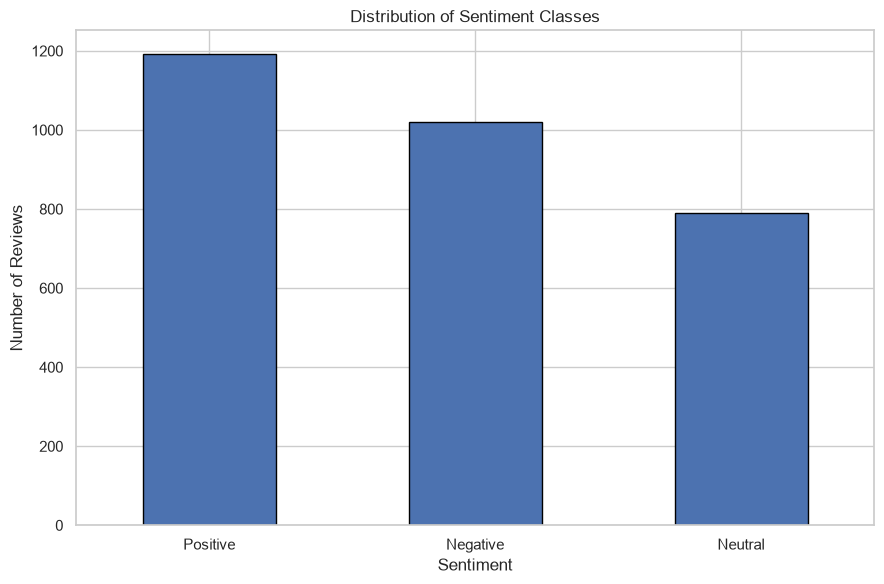

In [72]:
plt.figure(figsize=(9, 6))

sentiment_df["sentiment"].value_counts().plot(
    kind="bar",
    edgecolor="black"
)

plt.title("Distribution of Sentiment Classes")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

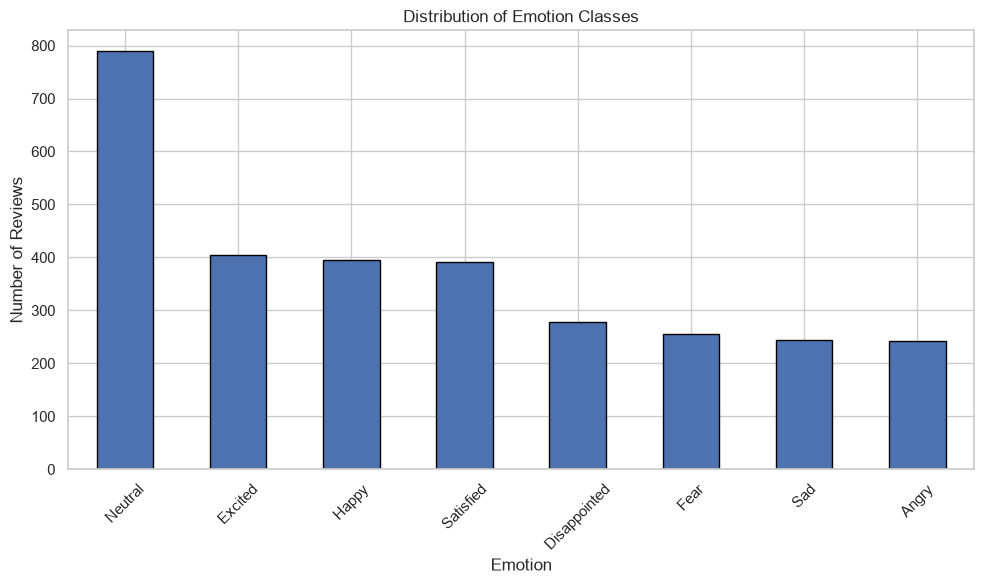

In [73]:
plt.figure(figsize=(10, 6))

sentiment_df["emotion"].value_counts().plot(
    kind="bar",
    edgecolor="black"
)

plt.title("Distribution of Emotion Classes")
plt.xlabel("Emotion")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [74]:
sentiment_emotion_table = pd.crosstab(
    sentiment_df["sentiment"],
    sentiment_df["emotion"]
)

display(sentiment_emotion_table)

emotion,Angry,Disappointed,Excited,Fear,Happy,Neutral,Sad,Satisfied
sentiment,,,,,,,,
Negative,242,278,0,255,0,0,244,0
Neutral,0,0,0,0,0,789,0,0
Positive,0,0,405,0,395,0,0,392


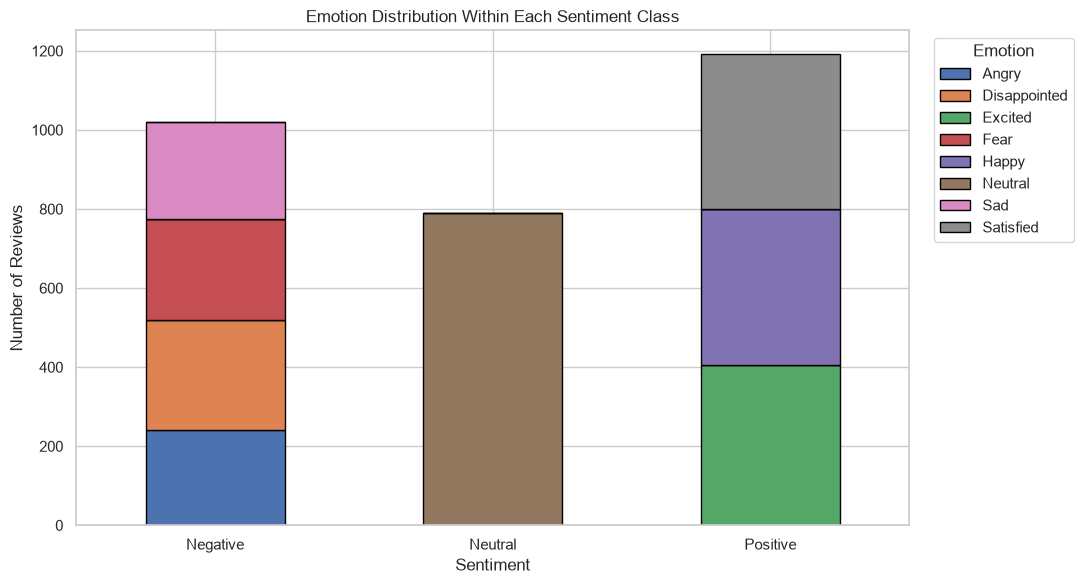

In [75]:
sentiment_emotion_table.plot(
    kind="bar",
    stacked=True,
    figsize=(11, 6),
    edgecolor="black"
)

plt.title("Emotion Distribution Within Each Sentiment Class")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.legend(title="Emotion", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [76]:
sentiment_counts = sentiment_df["sentiment"].value_counts()

balance_ratio = (
    sentiment_counts.min() / sentiment_counts.max()
)

print("Sentiment counts:")
print(sentiment_counts)

print(f"\nMinimum-to-maximum class ratio: {balance_ratio:.3f}")

if balance_ratio >= 0.80:
    print("The sentiment classes are reasonably balanced.")
else:
    print("The sentiment classes are not perfectly balanced.")

Sentiment counts:
sentiment
Positive    1192
Negative    1019
Neutral      789
Name: count, dtype: int64

Minimum-to-maximum class ratio: 0.662
The sentiment classes are not perfectly balanced.


In [77]:
X = sentiment_df["text"]
y = sentiment_df["sentiment"]

X_train_sentiment, X_test_sentiment, y_train_sentiment, y_test_sentiment = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

print("Training samples:", len(X_train_sentiment))
print("Testing samples:", len(X_test_sentiment))

Training samples: 2400
Testing samples: 600


In [78]:
logistic_sentiment_pipeline = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            ngram_range=(1, 2)
        )
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000,
            random_state=SEED
        )
    )
])

logistic_sentiment_pipeline.fit(
    X_train_sentiment,
    y_train_sentiment
)

logistic_predictions = logistic_sentiment_pipeline.predict(
    X_test_sentiment
)

In [79]:
logistic_accuracy = accuracy_score(
    y_test_sentiment,
    logistic_predictions
)

print(f"Logistic Regression Accuracy: {logistic_accuracy:.4f}")
print(f"Logistic Regression Accuracy: {logistic_accuracy * 100:.2f}%")

Logistic Regression Accuracy: 1.0000
Logistic Regression Accuracy: 100.00%


In [80]:
logistic_report = classification_report(
    y_test_sentiment,
    logistic_predictions,
    output_dict=True,
    zero_division=0
)

logistic_metrics = pd.DataFrame({
    "Precision": {
        label: logistic_report[label]["precision"]
        for label in sorted(y_test_sentiment.unique())
    },
    "Recall": {
        label: logistic_report[label]["recall"]
        for label in sorted(y_test_sentiment.unique())
    },
    "F1-Score": {
        label: logistic_report[label]["f1-score"]
        for label in sorted(y_test_sentiment.unique())
    }
})

display(logistic_metrics)

,Precision,Recall,F1-Score
Negative,1.0,1.0,1.0
Neutral,1.0,1.0,1.0
Positive,1.0,1.0,1.0


In [81]:
print(
    classification_report(
        y_test_sentiment,
        logistic_predictions,
        zero_division=0
    )
)

              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00       204
     Neutral       1.00      1.00      1.00       158
    Positive       1.00      1.00      1.00       238

    accuracy                           1.00       600
   macro avg       1.00      1.00      1.00       600
weighted avg       1.00      1.00      1.00       600



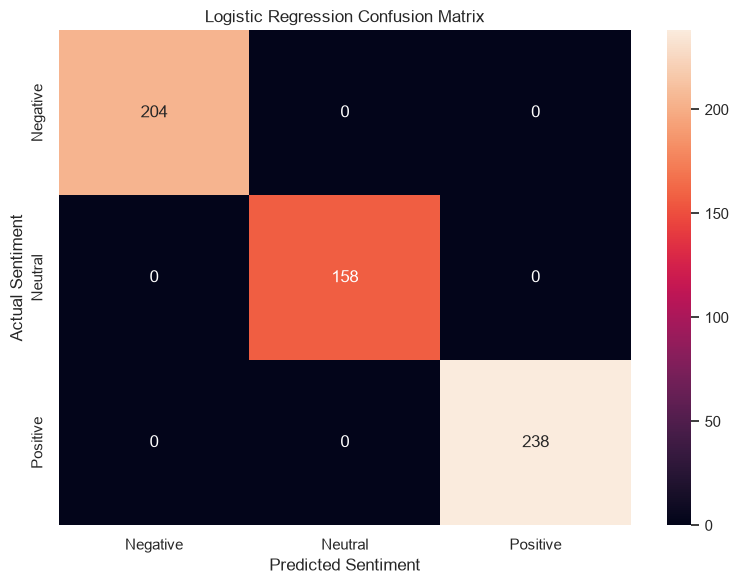

In [82]:
sentiment_labels = sorted(y_test_sentiment.unique())

cm_logistic = confusion_matrix(
    y_test_sentiment,
    logistic_predictions,
    labels=sentiment_labels
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm_logistic,
    annot=True,
    fmt="d",
    xticklabels=sentiment_labels,
    yticklabels=sentiment_labels
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted Sentiment")
plt.ylabel("Actual Sentiment")
plt.tight_layout()
plt.show()

### Q5.2 Interpretation

A TF-IDF representation combined with Logistic Regression was used to classify the review texts into sentiment categories. The accuracy and per-class precision, recall, and F1-scores provide a detailed view of the model's performance, while the confusion matrix shows which sentiment classes are most often confused. The results indicate how effectively classical TF-IDF features can capture sentiment-related information in this dataset.

In [83]:
from sklearn.naive_bayes import MultinomialNB

nb_sentiment_pipeline = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            ngram_range=(1, 2)
        )
    ),
    (
        "classifier",
        MultinomialNB()
    )
])

nb_sentiment_pipeline.fit(
    X_train_sentiment,
    y_train_sentiment
)

nb_predictions = nb_sentiment_pipeline.predict(
    X_test_sentiment
)

In [84]:
nb_accuracy = accuracy_score(
    y_test_sentiment,
    nb_predictions
)

nb_report = classification_report(
    y_test_sentiment,
    nb_predictions,
    output_dict=True,
    zero_division=0
)

print(f"Multinomial Naive Bayes Accuracy: {nb_accuracy:.4f}")
print(f"Multinomial Naive Bayes Accuracy: {nb_accuracy * 100:.2f}%")

Multinomial Naive Bayes Accuracy: 1.0000
Multinomial Naive Bayes Accuracy: 100.00%


In [85]:
nb_accuracy = accuracy_score(
    y_test_sentiment,
    nb_predictions
)

nb_report = classification_report(
    y_test_sentiment,
    nb_predictions,
    output_dict=True,
    zero_division=0
)

print(f"Multinomial Naive Bayes Accuracy: {nb_accuracy:.4f}")
print(f"Multinomial Naive Bayes Accuracy: {nb_accuracy * 100:.2f}%")

Multinomial Naive Bayes Accuracy: 1.0000
Multinomial Naive Bayes Accuracy: 100.00%


In [86]:
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Multinomial Naive Bayes"
    ],
    "Accuracy": [
        logistic_accuracy,
        nb_accuracy
    ],
    "Macro Precision": [
        logistic_report["macro avg"]["precision"],
        nb_report["macro avg"]["precision"]
    ],
    "Macro Recall": [
        logistic_report["macro avg"]["recall"],
        nb_report["macro avg"]["recall"]
    ],
    "Macro F1": [
        logistic_report["macro avg"]["f1-score"],
        nb_report["macro avg"]["f1-score"]
    ]
})

display(
    model_comparison.style.format({
        "Accuracy": "{:.4f}",
        "Macro Precision": "{:.4f}",
        "Macro Recall": "{:.4f}",
        "Macro F1": "{:.4f}"
    })
)

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,Logistic Regression,1.0000,1.0000,1.0000,1.0000
1,Multinomial Naive Bayes,1.0000,1.0000,1.0000,1.0000


In [87]:
if logistic_report["macro avg"]["f1-score"] >= nb_report["macro avg"]["f1-score"]:
    best_model_name = "Logistic Regression"
    best_model = logistic_sentiment_pipeline
    best_predictions = logistic_predictions
    best_accuracy = logistic_accuracy
else:
    best_model_name = "Multinomial Naive Bayes"
    best_model = nb_sentiment_pipeline
    best_predictions = nb_predictions
    best_accuracy = nb_accuracy

print("Best model based on macro F1-score:", best_model_name)
print(f"Best model accuracy: {best_accuracy:.4f}")

Best model based on macro F1-score: Logistic Regression
Best model accuracy: 1.0000


### Q5.3 Interpretation

The two models use the same TF-IDF features and the same training and testing data, so their performance can be compared fairly. The model with the higher macro F1-score is considered the better-performing model for this experiment because macro F1 gives equal importance to each sentiment class. Differences between Logistic Regression and Multinomial Naive Bayes can occur because the algorithms make different assumptions about how text features relate to the target classes.

In [88]:
misclassified = pd.DataFrame({
    "text": X_test_sentiment.reset_index(drop=True),
    "actual": y_test_sentiment.reset_index(drop=True),
    "predicted": pd.Series(best_predictions)
})

misclassified = misclassified[
    misclassified["actual"] != misclassified["predicted"]
].reset_index(drop=True)

print("Total misclassified examples:", len(misclassified))

display(misclassified.head(5))

Total misclassified examples: 0


,text,actual,predicted


In [89]:
positive_words = {
    "good", "great", "excellent", "amazing", "love",
    "loved", "best", "wonderful", "fantastic", "perfect"
}

negative_words = {
    "bad", "poor", "terrible", "awful", "worst",
    "hate", "hated", "horrible", "disappointing", "disappointed"
}

sarcasm_markers = {
    "yeah right",
    "sure",
    "great job",
    "what a surprise",
    "thanks a lot"
}


def explain_misclassification(text, actual, predicted):
    text_lower = text.lower()
    
    positive_count = sum(
        word in text_lower
        for word in positive_words
    )
    
    negative_count = sum(
        word in text_lower
        for word in negative_words
    )
    
    has_sarcasm_marker = any(
        marker in text_lower
        for marker in sarcasm_markers
    )
    
    if positive_count > 0 and negative_count > 0:
        return (
            "The review contains both positive and negative "
            "language, creating mixed sentiment that may be "
            "difficult for a bag-of-words model to interpret."
        )
    
    if has_sarcasm_marker:
        return (
            "The wording may contain sarcasm or an ironic expression, "
            "where the literal words do not represent the intended sentiment."
        )
    
    if actual == "Neutral" or predicted == "Neutral":
        return (
            "The wording may be relatively neutral or ambiguous, "
            "making the boundary between neutral and another sentiment difficult."
        )
    
    return (
        "The review may contain contextual or nuanced wording that "
        "is difficult to capture using TF-IDF word features alone."
    )

In [90]:
for i, row in misclassified.head(5).iterrows():
    explanation = explain_misclassification(
        row["text"],
        row["actual"],
        row["predicted"]
    )
    
    print("=" * 100)
    print(f"Misclassified Example {i + 1}")
    print("=" * 100)
    print("Text:")
    print(row["text"])
    print("\nActual sentiment:", row["actual"])
    print("Predicted sentiment:", row["predicted"])
    print("\nPlausible explanation:")
    print(explanation)

### Q5.4 Interpretation

The misclassified examples demonstrate that sentiment classification is not always straightforward. Some reviews contain mixed positive and negative language, while others may use ambiguous wording, contextual expressions, or sarcasm. These cases are difficult for a TF-IDF-based classifier because TF-IDF mainly represents the presence and importance of terms and does not fully understand the deeper context or intended meaning of a sentence.

In [91]:
%pip install transformers torch

Note: you may need to restart the kernel to use updated packages.


In [92]:
from transformers import pipeline

In [93]:
transformer_sentiment = pipeline(
    "sentiment-analysis",
    model="distilbert/distilbert-base-uncased-finetuned-sst-2-english"
)

Device set to use cpu


In [94]:
transformer_labels = sorted(
    set(result["label"] for result in transformer_results)
)

print("Transformer labels:")
print(transformer_labels)

print("\nDataset labels:")
print(sorted(sentiment_df["sentiment"].unique()))

NameError: name 'transformer_results' is not defined

### Q5.5 Optional Bonus — Transformer Comparison

The Hugging Face sentiment pipeline provides a pretrained Transformer-based sentiment model that can perform inference without training a classifier from scratch. Transformer models can capture contextual relationships between words much better than classical TF-IDF representations, but they generally require more computational resources and can have higher inference latency. TF-IDF models are lightweight, fast, and easy to train locally, while Transformer models require downloading pretrained model weights and can be considerably more resource-intensive. A direct accuracy comparison must also account for the label space: the dataset contains Positive, Negative, and Neutral labels, while the selected pretrained pipeline may use a different set of sentiment labels. Therefore, the comparison should only be reported as an accuracy score if the model's output labels are compatible with the dataset labels.

# Part 6: Named Entity Recognition (NER)

Named Entity Recognition (NER) is the task of identifying important entities in text and assigning them categories such as person, organization, location, date, money, or product. In this section, the dataset's ground-truth entities are compared with predictions from spaCy, and a simple rule-based regular-expression extractor is also evaluated.

In [ ]:
ner_path = os.path.join(DATA_PATH, "named_entity_recognition.csv")

ner_df = pd.read_csv(ner_path)

print("Dataset shape:", ner_df.shape)

print("\nColumns:")
print(ner_df.columns.tolist())

display(ner_df.head())

In [ ]:
print("Entity-related columns:")

for column in ner_df.columns:
    if "entit" in column.lower():
        print("-", column)

In [ ]:
ner_sample = ner_df.sample(
    5,
    random_state=SEED
)

for _, row in ner_sample.iterrows():
    print("=" * 100)
    print("SENTENCE:")
    print(row["text"])
    print("\nENTITIES:")
    print(row["entities"])
    print("\nENTITY TYPES:")
    print(row["entity_types"])

In [ ]:
for _, row in ner_sample.iterrows():
    print("=" * 100)
    print("SENTENCE:")
    print(row["text"])
    print("\nENTITIES:")
    
    entities = str(row["entities"]).split("|")
    entity_types = str(row["entity_types"]).split("|")
    
    for entity, entity_type in zip(entities, entity_types):
        entity = entity.strip()
        entity_type = entity_type.strip()
        
        if entity and entity.lower() != "nan":
            print(f"{entity_type}: {entity}")

### Q6.1 Interpretation

The five sampled sentences show that the dataset provides structured ground-truth entities and their corresponding entity types. Some sentences contain several different entity types, while others contain fewer entities because not every entity type occurs in every sentence.

In [ ]:
%pip install spacy

In [ ]:
!python -m spacy download en_core_web_sm

In [ ]:
import spacy

nlp = spacy.load("en_core_web_sm")

print("spaCy version:", spacy.__version__)
print("Model loaded successfully.")

In [ ]:
ner_test = ner_df.sample(
    20,
    random_state=SEED
).reset_index(drop=True)

print("Number of test sentences:", len(ner_test))

In [ ]:
def parse_ground_truth(row):
    entities = str(row["entities"]).split("|")
    entity_types = str(row["entity_types"]).split("|")
    
    ground_truth = []
    
    for entity, entity_type in zip(entities, entity_types):
        entity = entity.strip()
        entity_type = entity_type.strip().upper()
        
        if (
            entity
            and entity.lower() != "nan"
            and entity_type
            and entity_type.lower() != "nan"
        ):
            ground_truth.append(
                (entity, entity_type)
            )
    
    return ground_truth

In [ ]:
SPACY_TO_DATASET = {
    "PERSON": "PERSON",
    "ORG": "ORG",
    "GPE": "GPE",
    "LOC": "GPE",
    "DATE": "DATE",
    "MONEY": "MONEY",
    "PRODUCT": "PRODUCT"
}

VALID_ENTITY_TYPES = {
    "PERSON",
    "ORG",
    "GPE",
    "DATE",
    "MONEY",
    "PRODUCT"
}

In [ ]:
total_correct = 0
total_missed = 0
total_mislabeled = 0

detailed_results = []

for _, row in ner_test.iterrows():
    
    text = row["text"]
    
    ground_truth = parse_ground_truth(row)
    
    doc = nlp(text)
    
    predicted = []
    
    for ent in doc.ents:
        mapped_type = SPACY_TO_DATASET.get(ent.label_)
        
        if mapped_type in VALID_ENTITY_TYPES:
            predicted.append(
                (ent.text.strip(), mapped_type)
            )
    
    ground_truth_used = set()
    predicted_used = set()
    
    correct = []
    mislabeled = []
    missed = []
    
    # Exact entity + type matches
    for gt_entity, gt_type in ground_truth:
        
        found_exact = False
        
        for i, (pred_entity, pred_type) in enumerate(predicted):
            
            if i in predicted_used:
                continue
            
            if (
                pred_entity.lower() == gt_entity.lower()
                and pred_type == gt_type
            ):
                correct.append(
                    (gt_entity, gt_type)
                )
                
                ground_truth_used.add(
                    (gt_entity, gt_type)
                )
                
                predicted_used.add(i)
                
                found_exact = True
                break
        
        if found_exact:
            continue
        
        # Same entity text but wrong label
        found_wrong_label = False
        
        for i, (pred_entity, pred_type) in enumerate(predicted):
            
            if i in predicted_used:
                continue
            
            if pred_entity.lower() == gt_entity.lower():
                mislabeled.append(
                    (gt_entity, gt_type, pred_type)
                )
                
                ground_truth_used.add(
                    (gt_entity, gt_type)
                )
                
                predicted_used.add(i)
                
                found_wrong_label = True
                break
        
        if not found_wrong_label:
            missed.append(
                (gt_entity, gt_type)
            )
    
    total_correct += len(correct)
    total_missed += len(missed)
    total_mislabeled += len(mislabeled)
    
    detailed_results.append({
        "text": text,
        "ground_truth": ground_truth,
        "predicted": predicted,
        "correct": correct,
        "missed": missed,
        "mislabeled": mislabeled
    })

In [ ]:
print("=" * 70)
print("spaCy NER EVALUATION")
print("=" * 70)

print(f"Correctly identified entities: {total_correct}")
print(f"Missed entities:               {total_missed}")
print(f"Mislabeled entities:           {total_mislabeled}")

In [ ]:
for i, result in enumerate(detailed_results, start=1):
    
    print("=" * 100)
    print(f"Example {i}")
    print("=" * 100)
    
    print("Text:")
    print(result["text"])
    
    print("\nGround Truth:")
    print(result["ground_truth"])
    
    print("\nspaCy Predictions:")
    print(result["predicted"])
    
    print("\nCorrect:")
    print(result["correct"])
    
    print("\nMissed:")
    print(result["missed"])
    
    print("\nMislabeled:")
    print(result["mislabeled"])

### Q6.2 Interpretation

spaCy's pretrained English NER model was evaluated against the dataset's ground-truth entities on 20 randomly selected sentences. The comparison counts exact entity-and-type matches as correctly identified, entities present in the ground truth but not detected by spaCy as missed, and entities detected with the correct text span but an incorrect mapped type as mislabeled. Because the dataset contains clean, synthetic sentences, spaCy may perform differently from how it would perform on noisy real-world text.

In [ ]:
print(ner_df["entity_types"].head(10).to_string())

In [ ]:
print(ner_df["entity_types"].dtype)

In [ ]:
print(ner_df["entity_types"].dropna().unique()[:20])

In [ ]:
entity_types = [
    "PERSON",
    "ORG",
    "GPE",
    "DATE",
    "MONEY",
    "PRODUCT"
]

entity_type_counts = {}

for entity_type in entity_types:
    total = 0
    
    for value in ner_df["entity_types"].dropna():
        types = str(value).split(";")
        
        total += sum(
            1
            for t in types
            if t.strip().upper() == entity_type
        )
    
    entity_type_counts[entity_type] = total

entity_frequency_df = (
    pd.DataFrame.from_dict(
        entity_type_counts,
        orient="index",
        columns=["count"]
    )
    .sort_values("count", ascending=False)
)

display(entity_frequency_df)

In [ ]:
plt.figure(figsize=(10, 6))

plt.bar(
    entity_frequency_df.index,
    entity_frequency_df["count"],
    edgecolor="black"
)

plt.title("Frequency of Named Entity Types")
plt.xlabel("Entity Type")
plt.ylabel("Number of Entity Occurrences")

plt.tight_layout()
plt.show()

In [ ]:
most_common_entity = entity_frequency_df.index[0]
most_common_count = entity_frequency_df.iloc[0]["count"]

print(
    f"Most common entity type: {most_common_entity}"
)

print(
    f"Number of occurrences: {most_common_count}"
)

### Q6.3 Interpretation

The bar chart shows the frequency of each named entity type across the complete dataset. The most common entity type is identified directly from the calculated frequencies. Because the dataset was synthetically generated using structured templates, some entity types may occur more frequently because they are included in more sentence patterns or because particular sentence templates consistently contain those types.

In [ ]:
money_pattern = re.compile(
    r"""
    (?:
        [$€£]\s?\d+(?:,\d{3})*(?:\.\d{2})?
        |
        \d+(?:,\d{3})*(?:\.\d{2})?\s?(?:USD|EUR|GBP)
    )
    """,
    re.VERBOSE | re.IGNORECASE
)

In [ ]:
money_test_text = """
The product costs $199.99 and the shipping fee is $25.00.
Another version costs €500.
"""

print("Text:")
print(money_test_text)

print("\nDetected MONEY entities:")

matches = money_pattern.findall(money_test_text)

for match in matches:
    print(match)

In [ ]:
def normalize_money(value):
    if pd.isna(value):
        return set()
    
    value = str(value).strip()
    
    if not value or value.lower() == "nan":
        return set()
    
    parts = value.split("|")
    
    return {
        part.strip().lower()
        for part in parts
        if part.strip()
    }

In [ ]:
true_positive = 0
false_positive = 0
false_negative = 0

money_evaluation = []

for _, row in ner_df.iterrows():
    
    text = str(row["text"])
    
    predicted_money = {
        match.strip().lower()
        for match in money_pattern.findall(text)
    }
    
    actual_money = normalize_money(
        row["money"]
    )
    
    tp = len(
        predicted_money & actual_money
    )
    
    fp = len(
        predicted_money - actual_money
    )
    
    fn = len(
        actual_money - predicted_money
    )
    
    true_positive += tp
    false_positive += fp
    false_negative += fn
    
    money_evaluation.append({
        "text": text,
        "actual": actual_money,
        "predicted": predicted_money,
        "TP": tp,
        "FP": fp,
        "FN": fn
    })

In [ ]:
money_precision = (
    true_positive /
    (true_positive + false_positive)
    if (true_positive + false_positive) > 0
    else 0
)

money_recall = (
    true_positive /
    (true_positive + false_negative)
    if (true_positive + false_negative) > 0
    else 0
)

print("MONEY Entity Extractor")
print("=" * 50)

print(f"True Positives:  {true_positive}")
print(f"False Positives: {false_positive}")
print(f"False Negatives: {false_negative}")

print(f"\nPrecision: {money_precision:.4f}")
print(f"Recall:    {money_recall:.4f}")

In [ ]:
for result in money_evaluation[:10]:
    print("=" * 100)
    print("Text:", result["text"])
    print("Actual:", result["actual"])
    print("Predicted:", result["predicted"])
    print(
        f"TP={result['TP']}, "
        f"FP={result['FP']}, "
        f"FN={result['FN']}"
    )

### Q6.4 Interpretation

A regular-expression-based rule was used to identify monetary expressions in the text. The extractor was evaluated against the dataset's ground-truth money column using precision and recall. Because the dataset uses relatively clean and structured synthetic sentences, a simple regular expression can perform well when monetary expressions follow predictable formats; however, such rules can be less reliable when money is expressed in unexpected ways.

### Q6.5 Discussion

Rule-based NER systems depend on manually designed patterns, so they work well only when entities follow predictable formats. A purely statistical NER system can learn useful patterns from training data, but its performance can decrease when the text differs significantly from the training examples. Neural and Transformer-based NER systems can capture richer contextual relationships between words and are generally more flexible when dealing with varied language. This becomes especially important in real-world text such as social media, where spelling mistakes, abbreviations, emojis, slang, hashtags, and incomplete sentences are common. Rule-based systems may miss entities when their wording does not match the predefined patterns, while statistical systems may struggle with unfamiliar entities or contexts. Transformer-based models usually require more computational resources and suitable training or fine-tuning data, but they can provide stronger contextual understanding than simple rules.

# Part 7: Multi-Class Text Classification

Multi-class text classification assigns a text document to one of several possible categories. In this section, the distribution of categories and difficulty levels is explored, followed by a TF-IDF classification pipeline, cross-validation, detailed evaluation, difficulty-based evaluation, and interpretation of important TF-IDF features.

In [ ]:
import os
classification_path = os.path.join(
    DATA_PATH,
    "text_classification.csv"
)

classification_df = pd.read_csv(
    classification_path
)

print("Dataset shape:", classification_df.shape)

print("\nColumns:")
print(classification_df.columns.tolist())

display(classification_df.head())

In [ ]:
category_counts = classification_df["category"].value_counts()

print("Category distribution:")
display(category_counts)

print(
    "\nNumber of categories:",
    classification_df["category"].nunique()
)

print(
    "Minimum category count:",
    category_counts.min()
)

print(
    "Maximum category count:",
    category_counts.max()
)

In [ ]:
plt.figure(figsize=(12, 6))

category_counts.sort_values().plot(
    kind="barh",
    edgecolor="black"
)

plt.title("Distribution of News Categories")
plt.xlabel("Number of Documents")
plt.ylabel("Category")

plt.tight_layout()
plt.show()

In [ ]:
if category_counts.nunique() == 1:
    print("The dataset is perfectly balanced across categories.")
else:
    print("The dataset is not perfectly balanced across categories.")

print("\nCategory counts:")
print(category_counts)

In [ ]:
difficulty_by_category = pd.crosstab(
    classification_df["category"],
    classification_df["difficulty"]
)

display(difficulty_by_category)

In [ ]:
difficulty_by_category.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 7),
    edgecolor="black"
)

plt.title("Difficulty Distribution Within Each Category")
plt.xlabel("Category")
plt.ylabel("Number of Documents")
plt.xticks(rotation=45, ha="right")
plt.legend(
    title="Difficulty",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

### Q7.1 Interpretation

The category distribution shows how the 3,000 documents are divided among the 10 news categories. The category counts are compared to determine whether the classification dataset is balanced. The stacked bar chart also shows how Beginner, Intermediate, and Advanced examples are distributed within each category, allowing differences in difficulty across topics to be observed.

In [ ]:
X_classification = classification_df["text"]
y_classification = classification_df["category"]

print("Number of samples:", len(X_classification))
print("Number of classes:", y_classification.nunique())

In [ ]:
classification_pipeline = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            ngram_range=(1, 2)
        )
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000,
            random_state=SEED
        )
    )
])

print(classification_pipeline)

In [ ]:
classification_pipeline = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            ngram_range=(1, 2)
        )
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000,
            random_state=SEED
        )
    )
])

print(classification_pipeline)

### Q7.2 Interpretation

The TF-IDF and Logistic Regression models were combined into a single scikit-learn Pipeline and evaluated using 5-fold cross-validation. The mean accuracy represents the average performance across the five folds, while the standard deviation shows how much the performance varies between folds. A small standard deviation indicates that the model performs relatively consistently across different portions of the dataset.

In [ ]:
X_train_classification, X_test_classification, y_train_classification, y_test_classification = train_test_split(
    X_classification,
    y_classification,
    test_size=0.20,
    random_state=SEED,
    stratify=y_classification
)

print("Training samples:", len(X_train_classification))
print("Testing samples:", len(X_test_classification))

In [ ]:
classification_pipeline.fit(
    X_train_classification,
    y_train_classification
)

classification_predictions = classification_pipeline.predict(
    X_test_classification
)

print("Model training completed.")

In [ ]:
classification_report_dict = classification_report(
    y_test_classification,
    classification_predictions,
    output_dict=True,
    zero_division=0
)

classification_report_df = pd.DataFrame(
    classification_report_dict
).transpose()

display(
    classification_report_df.style.format(
        "{:.4f}"
    )
)

In [ ]:
classification_accuracy = accuracy_score(
    y_test_classification,
    classification_predictions
)

print(
    f"Test Accuracy: {classification_accuracy:.4f}"
)

print(
    f"Test Accuracy: {classification_accuracy * 100:.2f}%"
)

In [ ]:
class_metrics = classification_report_df.loc[
    sorted(y_test_classification.unique()),
    ["precision", "recall", "f1-score"]
]

hardest_category = class_metrics["f1-score"].idxmin()
hardest_f1 = class_metrics.loc[
    hardest_category,
    "f1-score"
]

print("Hardest category:", hardest_category)
print(f"F1-score: {hardest_f1:.4f}")

### Q7.3 Interpretation

The held-out test set provides an unbiased evaluation of the trained classification pipeline. Precision, recall, and F1-score show that performance can differ between categories even when the overall accuracy is high. The category with the lowest F1-score is considered the hardest category for this model. This may happen when its vocabulary overlaps with another category, causing TF-IDF to assign similar importance to words that occur in multiple topics.

In [ ]:
test_results = pd.DataFrame({
    "text": X_test_classification.reset_index(drop=True),
    "actual": y_test_classification.reset_index(drop=True),
    "predicted": pd.Series(classification_predictions)
})

test_results["difficulty"] = classification_df.loc[
    X_test_classification.index,
    "difficulty"
].reset_index(drop=True)

display(test_results.head())

In [ ]:
beginner_results = test_results[
    test_results["difficulty"] == "Beginner"
]

advanced_results = test_results[
    test_results["difficulty"] == "Advanced"
]

beginner_accuracy = accuracy_score(
    beginner_results["actual"],
    beginner_results["predicted"]
)

advanced_accuracy = accuracy_score(
    advanced_results["actual"],
    advanced_results["predicted"]
)

print(
    f"Beginner Accuracy: {beginner_accuracy:.4f}"
)

print(
    f"Advanced Accuracy: {advanced_accuracy:.4f}"
)

print(
    f"\nBeginner samples: {len(beginner_results)}"
)

print(
    f"Advanced samples: {len(advanced_results)}"
)

In [ ]:
difficulty_comparison = pd.DataFrame({
    "Difficulty": [
        "Beginner",
        "Advanced"
    ],
    "Number of Samples": [
        len(beginner_results),
        len(advanced_results)
    ],
    "Accuracy": [
        beginner_accuracy,
        advanced_accuracy
    ]
})

display(
    difficulty_comparison.style.format({
        "Accuracy": "{:.4f}"
    })
)

In [ ]:
accuracy_difference = beginner_accuracy - advanced_accuracy

print(
    f"Beginner - Advanced accuracy difference: "
    f"{accuracy_difference:.4f}"
)

if abs(accuracy_difference) < 0.05:
    print(
        "The difference is relatively small, so performance "
        "does not vary meaningfully between the two difficulty levels."
    )
else:
    print(
        "There is a noticeable difference in performance "
        "between the two difficulty levels."
    )

### Q7.4 Interpretation

The model's accuracy was calculated separately for Beginner and Advanced examples in the held-out test set. Comparing these two values shows whether the difficulty rating corresponds to a meaningful change in classification performance. Advanced examples may be harder because their vocabulary or descriptions can contain more subtle topic distinctions, although the difference may be small if the synthetic dataset uses clear and repetitive category-specific language.

In [ ]:
selected_categories = sorted(
    classification_df["category"].unique()
)[:2]

print("Selected categories:")
print(selected_categories)

In [ ]:
tfidf_vectorizer = classification_pipeline.named_steps["tfidf"]
classifier = classification_pipeline.named_steps["classifier"]

feature_names = tfidf_vectorizer.get_feature_names_out()

print("Number of TF-IDF features:", len(feature_names))
print("Number of classifier classes:", len(classifier.classes_))

In [ ]:
for category in selected_categories:
    
    category_index = list(
        classifier.classes_
    ).index(category)
    
    coefficients = classifier.coef_[category_index]
    
    top_indices = coefficients.argsort()[-10:][::-1]
    
    top_features = pd.DataFrame({
        "Feature": feature_names[top_indices],
        "Coefficient": coefficients[top_indices]
    })
    
    print("=" * 60)
    print(f"Top 10 TF-IDF Features for: {category}")
    print("=" * 60)
    
    display(
        top_features.style.format({
            "Coefficient": "{:.4f}"
        })
    )

In [ ]:
for category in selected_categories:
    
    category_index = list(
        classifier.classes_
    ).index(category)
    
    coefficients = classifier.coef_[category_index]
    
    top_indices = coefficients.argsort()[-10:][::-1]
    
    top_features = pd.Series(
        coefficients[top_indices],
        index=feature_names[top_indices]
    ).sort_values()
    
    plt.figure(figsize=(10, 6))
    
    plt.barh(
        top_features.index,
        top_features.values,
        edgecolor="black"
    )
    
    plt.title(
        f"Top 10 TF-IDF Features for {category}"
    )
    
    plt.xlabel("Logistic Regression Coefficient")
    plt.ylabel("TF-IDF Feature")
    
    plt.tight_layout()
    plt.show()

### Q7.5 Interpretation

The most important TF-IDF features for the two selected categories represent words or phrases that strongly influence the classifier toward those categories. If these features are closely related to the topics represented by their categories, then the model appears to have learned meaningful topic-specific vocabulary. Some features may be less intuitive because words can occur across multiple categories, especially when the dataset contains overlapping topics.

# Part 8: Sentence Similarity & Semantic Relationships

Sentence similarity measures how closely two pieces of text are related in meaning or content. In this section, TF-IDF vectors and cosine similarity are used to calculate similarity between sentence pairs and compare the calculated values with the dataset's ground-truth similarity scores. The limitations of word-overlap-based similarity are also examined using contradiction examples.

In [ ]:
similarity_path = os.path.join(
    DATA_PATH,
    "text_similarity.csv"
)

similarity_df = pd.read_csv(
    similarity_path
)

print("Dataset shape:", similarity_df.shape)

print("\nColumns:")
print(similarity_df.columns.tolist())

display(similarity_df.head())

In [ ]:
print(similarity_df.info())

print("\nMissing values:")
display(similarity_df.isnull().sum())

print("\nRelationship types:")
print(
    similarity_df["relationship"].value_counts()
)

In [ ]:
print("Similarity score statistics:")
display(
    similarity_df["similarity_score"].describe()
)

print(
    "\nMinimum:",
    similarity_df["similarity_score"].min()
)

print(
    "Maximum:",
    similarity_df["similarity_score"].max()
)

In [ ]:
print("Column names:")
for i, column in enumerate(similarity_df.columns, start=1):
    print(f"{i}. {column}")

In [ ]:
sentence1_col = "sentence_1"
sentence2_col = "sentence_2"

all_sentences = pd.concat([
    similarity_df[sentence1_col],
    similarity_df[sentence2_col]
]).astype(str)

print("Total sentences used for TF-IDF:", len(all_sentences))

In [ ]:
similarity_vectorizer = TfidfVectorizer(
    lowercase=True
)

tfidf_matrix = similarity_vectorizer.fit_transform(
    all_sentences
)

print("TF-IDF matrix shape:", tfidf_matrix.shape)

In [ ]:
n_pairs = len(similarity_df)

sentence1_vectors = tfidf_matrix[:n_pairs]
sentence2_vectors = tfidf_matrix[n_pairs:]

print(
    "Sentence 1 matrix:",
    sentence1_vectors.shape
)

print(
    "Sentence 2 matrix:",
    sentence2_vectors.shape
)

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

In [ ]:
tfidf_similarity_scores = []

for i in range(n_pairs):
    
    score = cosine_similarity(
        sentence1_vectors[i],
        sentence2_vectors[i]
    )[0][0]
    
    tfidf_similarity_scores.append(score)

similarity_df["tfidf_similarity"] = (
    tfidf_similarity_scores
)

display(
    similarity_df[
        [
            sentence1_col,
            sentence2_col,
            "similarity_score",
            "tfidf_similarity"
        ]
    ].head(10)
)

In [ ]:
pearson_correlation = similarity_df[
    "tfidf_similarity"
].corr(
    similarity_df["similarity_score"],
    method="pearson"
)

print(
    f"Pearson correlation coefficient: "
    f"{pearson_correlation:.4f}"
)

In [ ]:
plt.figure(figsize=(10, 7))

plt.scatter(
    similarity_df["tfidf_similarity"],
    similarity_df["similarity_score"],
    alpha=0.5
)

plt.title(
    "TF-IDF Cosine Similarity vs Dataset Similarity Score"
)

plt.xlabel(
    "TF-IDF Cosine Similarity"
)

plt.ylabel(
    "Dataset Similarity Score"
)

plt.tight_layout()
plt.show()

In [ ]:
print("=" * 60)
print("Q8.1 SUMMARY")
print("=" * 60)

print(
    f"Number of sentence pairs: {len(similarity_df)}"
)

print(
    f"Pearson correlation: {pearson_correlation:.4f}"
)

### Q8.1 Interpretation

TF-IDF cosine similarity was calculated for every sentence pair and compared with the dataset's similarity score. The scatter plot shows how closely the two measurements are related. The Pearson correlation coefficient measures the strength of the linear relationship between the TF-IDF-based score and the dataset's ground-truth score. A higher positive correlation indicates that TF-IDF is better aligned with the similarity labels, while a lower correlation shows that simple word overlap does not fully capture semantic similarity.

In [ ]:
relationship_statistics = (
    similarity_df
    .groupby("relationship")["tfidf_similarity"]
    .agg(
        ["count", "mean", "median", "std"]
    )
    .sort_values(
        "mean",
        ascending=False
    )
)

display(relationship_statistics)

In [ ]:
plt.figure(figsize=(12, 7))

sns.boxplot(
    data=similarity_df,
    x="relationship",
    y="tfidf_similarity"
)

plt.title(
    "TF-IDF Cosine Similarity by Relationship Type"
)

plt.xlabel("Relationship Type")
plt.ylabel("TF-IDF Cosine Similarity")

plt.xticks(
    rotation=30,
    ha="right"
)

plt.tight_layout()
plt.show()

In [ ]:
relationship_ranking = (
    similarity_df
    .groupby("relationship")["tfidf_similarity"]
    .mean()
    .sort_values(ascending=False)
)

print("Relationship ranking from highest to lowest TF-IDF similarity:")
print()

for rank, (relationship, score) in enumerate(
    relationship_ranking.items(),
    start=1
):
    print(
        f"{rank}. {relationship}: {score:.4f}"
    )

### Q8.2 Interpretation

The boxplot shows the distribution of TF-IDF cosine similarity for each relationship type. Ideally, Same Meaning and Paraphrase pairs should receive higher similarity scores than Related, Contradiction, and Unrelated pairs. However, TF-IDF is based mainly on word overlap rather than meaning, so some Contradiction or Related pairs can receive high scores when they share many words. This is one of the main limitations of using TF-IDF as a semantic similarity method.

In [ ]:
contradiction_df = similarity_df[
    similarity_df["relationship"].str.strip().str.lower()
    == "contradiction"
].copy()

print(
    "Number of contradiction pairs:",
    len(contradiction_df)
)

In [ ]:
contradiction_samples = contradiction_df.sample(
    n=3,
    random_state=SEED
).reset_index(drop=True)

display(
    contradiction_samples[
        [
            sentence1_col,
            sentence2_col,
            "tfidf_similarity",
            "similarity_score"
        ]
    ]
)

In [ ]:
for i, row in contradiction_samples.iterrows():
    
    print("=" * 100)
    print(f"CONTRADICTION PAIR {i + 1}")
    print("=" * 100)
    
    print("Sentence 1:")
    print(row[sentence1_col])
    
    print("\nSentence 2:")
    print(row[sentence2_col])
    
    print(
        f"\nTF-IDF Cosine Similarity: "
        f"{row['tfidf_similarity']:.4f}"
    )
    
    print(
        f"Dataset Similarity Score: "
        f"{row['similarity_score']:.4f}"
    )

### Q8.3 Explanation

TF-IDF can assign a relatively high similarity score to contradiction pairs because the two sentences may contain many of the same words. For example, the sentences "The team won the championship" and "The team lost the championship" share the words "team" and "championship", even though their meanings are opposite. TF-IDF measures the importance and overlap of words but does not understand whether a word such as "won" expresses an opposite meaning to "lost". Therefore, a word-overlap-based method can confuse contradictions with paraphrases when the sentences use similar vocabulary. This demonstrates why semantic similarity requires contextual understanding rather than only counting shared words.

In [ ]:
%pip install sentence-transformers

In [ ]:
from sentence_transformers import SentenceTransformer

embedding_model = SentenceTransformer(
    "all-MiniLM-L6-v2"
)

print("Sentence embedding model loaded successfully.")

In [ ]:
sentence1_texts = (
    similarity_df[sentence1_col]
    .astype(str)
    .tolist()
)

sentence2_texts = (
    similarity_df[sentence2_col]
    .astype(str)
    .tolist()
)

print(
    "Sentence pairs:",
    len(sentence1_texts)
)

In [ ]:
sentence1_embeddings = embedding_model.encode(
    sentence1_texts,
    show_progress_bar=True
)

sentence2_embeddings = embedding_model.encode(
    sentence2_texts,
    show_progress_bar=True
)

print(
    "Sentence 1 embedding shape:",
    sentence1_embeddings.shape
)

print(
    "Sentence 2 embedding shape:",
    sentence2_embeddings.shape
)

In [ ]:
embedding_similarity_scores = []

for i in range(len(similarity_df)):
    
    score = cosine_similarity(
        [sentence1_embeddings[i]],
        [sentence2_embeddings[i]]
    )[0][0]
    
    embedding_similarity_scores.append(score)

similarity_df["embedding_similarity"] = (
    embedding_similarity_scores
)

display(
    similarity_df[
        [
            sentence1_col,
            sentence2_col,
            "similarity_score",
            "embedding_similarity"
        ]
    ].head(10)
)

In [ ]:
embedding_correlation = similarity_df[
    "embedding_similarity"
].corr(
    similarity_df["similarity_score"],
    method="pearson"
)

print(
    f"Embedding Pearson correlation: "
    f"{embedding_correlation:.4f}"
)

print(
    f"TF-IDF Pearson correlation: "
    f"{pearson_correlation:.4f}"
)

In [ ]:
correlation_comparison = pd.DataFrame({
    "Method": [
        "TF-IDF Cosine Similarity",
        "Sentence Embedding Cosine Similarity"
    ],
    "Pearson Correlation": [
        pearson_correlation,
        embedding_correlation
    ]
})

display(
    correlation_comparison.style.format({
        "Pearson Correlation": "{:.4f}"
    })
)

In [ ]:
if abs(embedding_correlation) > abs(pearson_correlation):
    better_method = "Sentence Embeddings"
    better_score = embedding_correlation
else:
    better_method = "TF-IDF"
    better_score = pearson_correlation

print(
    f"Stronger correlation: {better_method}"
)

print(
    f"Correlation: {better_score:.4f}"
)

In [ ]:
plt.figure(figsize=(10, 7))

plt.scatter(
    similarity_df["embedding_similarity"],
    similarity_df["similarity_score"],
    alpha=0.5
)

plt.title(
    "Sentence Embedding Similarity vs Dataset Similarity Score"
)

plt.xlabel(
    "Embedding Cosine Similarity"
)

plt.ylabel(
    "Dataset Similarity Score"
)

plt.tight_layout()
plt.show()

### Q8.4 Interpretation

The pretrained sentence-embedding model was used to represent each sentence as a dense vector containing contextual semantic information. Its cosine similarity was then compared with the dataset's ground-truth similarity score using Pearson correlation. Sentence embeddings are expected to perform better when semantic relationships depend on meaning rather than exact word overlap because they capture contextual relationships between words and sentences. TF-IDF mainly measures shared vocabulary, so it can assign high similarity to sentences that use similar words even when their meanings differ. The method with the higher absolute Pearson correlation provides the stronger alignment with the dataset's similarity scores.

# Part 9: Word Embeddings & Semantic Relationships

Word embeddings represent words as numerical vectors in a continuous vector space. Words with related meanings can have similar vector representations. In this section, the relationships in the word embedding dataset are explored, a Word2Vec model is trained using text from the dataset collection, and the learned embeddings are used to calculate similarities and find nearest neighbors.

In [ ]:
import os
word_embedding_path = os.path.join(
    DATA_PATH,
    "word_embeddings.csv"
)

word_embeddings_df = pd.read_csv(
    word_embedding_path
)

print("Dataset shape:", word_embeddings_df.shape)

print("\nColumns:")
print(word_embeddings_df.columns.tolist())

display(word_embeddings_df.head())

In [ ]:
print(word_embeddings_df.info())

print("\nMissing values:")
display(word_embeddings_df.isnull().sum())

print("\nRelationship types:")
print(
    word_embeddings_df["relationship"].value_counts()
)

In [ ]:
relationship_similarity = (
    word_embeddings_df
    .groupby("relationship")["similarity_score"]
    .agg(
        ["count", "mean", "median", "std"]
    )
    .sort_values(
        "mean",
        ascending=False
    )
)

display(
    relationship_similarity.style.format({
        "mean": "{:.4f}",
        "median": "{:.4f}",
        "std": "{:.4f}"
    })
)

In [ ]:
plt.figure(figsize=(12, 7))

relationship_means = (
    word_embeddings_df
    .groupby("relationship")["similarity_score"]
    .mean()
    .sort_values(ascending=False)
)

plt.bar(
    relationship_means.index,
    relationship_means.values,
    edgecolor="black"
)

plt.title(
    "Average Similarity Score by Word Relationship"
)

plt.xlabel("Relationship Type")
plt.ylabel("Average Similarity Score")

plt.xticks(
    rotation=35,
    ha="right"
)

plt.tight_layout()
plt.show()

In [ ]:
print(
    "Relationship types ranked by average similarity:"
)

for rank, (relationship, score) in enumerate(
    relationship_means.items(),
    start=1
):
    print(
        f"{rank}. {relationship}: {score:.4f}"
    )

### Q9.1 Interpretation

The average similarity score was calculated for each word relationship and visualized using a bar chart. Synonym pairs would intuitively be expected to have high similarity because they have closely related meanings, while Antonym pairs may be surprising because antonyms can be semantically related even though their meanings are opposite. Other relationships such as Category Member, Related Concept, Profession, Location, Object, and Action can also receive relatively high scores because words can be strongly associated without being synonyms.

In [ ]:
%pip install gensim

In [ ]:
from gensim.models import Word2Vec

print("Gensim Word2Vec imported successfully.")

In [ ]:
text_corpus = []

csv_files = [
    "nlp_basics.csv",
    "text_preprocessing.csv",
    "bow_tfidf.csv",
    "ngrams.csv",
    "sentiment_analysis.csv",
    "text_classification.csv",
    "text_similarity.csv"
]

for filename in csv_files:
    
    file_path = os.path.join(
        DATA_PATH,
        filename
    )
    
    temp_df = pd.read_csv(file_path)
    
    text_columns = temp_df.select_dtypes(
        include=["object", "string"]
    ).columns
    
    for column in text_columns:
        
        for text in temp_df[column].dropna():
            
            text_corpus.append(
                str(text)
            )

print(
    "Number of text entries in corpus:",
    len(text_corpus)
)

In [ ]:
import re

tokenized_corpus = []

for text in text_corpus:
    
    tokens = re.findall(
        r"\b[a-zA-Z]+\b",
        text.lower()
    )
    
    if tokens:
        tokenized_corpus.append(tokens)

print(
    "Number of tokenized documents:",
    len(tokenized_corpus)
)

print(
    "\nExample tokenized sentence:"
)

print(tokenized_corpus[0])

In [ ]:
word2vec_model = Word2Vec(
    sentences=tokenized_corpus,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    sg=1,
    epochs=20,
    seed=SEED
)

print("Word2Vec training completed.")

In [ ]:
vocabulary_size = len(
    word2vec_model.wv.key_to_index
)

print(
    "Word2Vec vocabulary size:",
    vocabulary_size
)

In [ ]:
print(
    "Word embedding dataset columns:"
)

for i, column in enumerate(
    word_embeddings_df.columns,
    start=1
):
    print(f"{i}. {column}")

In [ ]:
word1_col = "word"
word2_col = "related_word"

print(
    "Word 1 column:",
    word1_col
)

print(
    "Word 2 column:",
    word2_col
)

In [ ]:
valid_pairs = []

for _, row in word_embeddings_df.iterrows():
    
    word1 = str(row[word1_col]).lower().strip()
    word2 = str(row[word2_col]).lower().strip()
    
    if (
        word1 in word2vec_model.wv.key_to_index
        and
        word2 in word2vec_model.wv.key_to_index
    ):
        valid_pairs.append(
            row
        )

valid_pairs_df = pd.DataFrame(
    valid_pairs
)

print(
    "Number of word pairs available in vocabulary:",
    len(valid_pairs_df)
)

In [ ]:
sample_pairs = valid_pairs_df.sample(
    n=10,
    random_state=SEED
).copy()

sample_pairs = sample_pairs.reset_index(
    drop=True
)

display(sample_pairs)

In [ ]:
model_similarities = []

for _, row in sample_pairs.iterrows():
    
    word1 = str(
        row[word1_col]
    ).lower().strip()
    
    word2 = str(
        row[word2_col]
    ).lower().strip()
    
    similarity = (
        word2vec_model.wv.similarity(
            word1,
            word2
        )
    )
    
    model_similarities.append(
        similarity
    )

sample_pairs["word2vec_similarity"] = (
    model_similarities
)

comparison_df = sample_pairs[
    [
        word1_col,
        word2_col,
        "relationship",
        "similarity_score",
        "word2vec_similarity"
    ]
]

display(
    comparison_df.style.format({
        "similarity_score": "{:.4f}",
        "word2vec_similarity": "{:.4f}"
    })
)

In [ ]:
comparison_df = comparison_df.copy()

comparison_df["absolute_difference"] = (
    abs(
        comparison_df["similarity_score"]
        -
        comparison_df["word2vec_similarity"]
    )
)

display(
    comparison_df.style.format({
        "similarity_score": "{:.4f}",
        "word2vec_similarity": "{:.4f}",
        "absolute_difference": "{:.4f}"
    })
)

### Q9.2 Interpretation

A Word2Vec model was trained on text collected from several datasets in the NLP collection. Ten word pairs were then selected from `word_embeddings.csv` and their cosine similarities were calculated using the learned word vectors. The Word2Vec scores do not necessarily match the dataset's approximate similarity scores exactly because the model learns relationships from the training corpus rather than from the provided similarity labels. Differences are expected because the training corpus is limited and the meaning of a word depends strongly on the contexts in which it appears.

In [ ]:
selected_words = []

for word in (
    word_embeddings_df[word1_col]
    .astype(str)
    .str.lower()
    .str.strip()
):
    
    if word in word2vec_model.wv.key_to_index:
        
        if word not in selected_words:
            selected_words.append(word)
    
    if len(selected_words) == 3:
        break

print(
    "Selected words:"
)

print(selected_words)

In [ ]:
for word in selected_words:
    
    print("=" * 60)
    print(f"Nearest neighbors for: {word}")
    print("=" * 60)
    
    neighbors = word2vec_model.wv.most_similar(
        word,
        topn=5
    )
    
    for rank, (neighbor, score) in enumerate(
        neighbors,
        start=1
    ):
        print(
            f"{rank}. {neighbor}: {score:.4f}"
        )
    
    print()

### Q9.3 Interpretation

The five nearest neighbors for each selected word were obtained from the trained Word2Vec embedding space. Some neighbors may be semantically related to the original word because Word2Vec learns from words appearing in similar contexts. However, the results may also contain unexpected or weakly related words because the training corpus is relatively small and synthetically generated for educational purposes. A larger and more diverse corpus would generally provide richer contextual information and more reliable word relationships.

### Q9.4 Explanation

Word embeddings represent words as numerical vectors in a continuous space where relationships between words can be represented by directions and distances. During training, words that occur in similar contexts receive similar vector representations. As a result, relationships such as gender can appear as a consistent direction in the vector space, allowing an operation such as "king - man + woman" to move toward the vector representing "queen". Bag-of-Words and TF-IDF do not naturally capture this type of relationship because they represent words mainly as independent dimensions based on word occurrence and frequency. They do not learn a continuous semantic space where relationships between words can be represented through vector arithmetic.

# Part 10: Transformer-Era NLP Tasks

Transformers are modern NLP models that use attention mechanisms to understand relationships between words and their surrounding context. In this section, different transformer-era NLP tasks are explored using the transformer examples dataset and pretrained Hugging Face pipelines.

In [ ]:
transformer_path = os.path.join(
    DATA_PATH,
    "transformer_examples.csv"
)

transformer_df = pd.read_csv(
    transformer_path
)

print("Dataset shape:", transformer_df.shape)

print("\nColumns:")
print(transformer_df.columns.tolist())

display(transformer_df.head())

In [ ]:
print(transformer_df.info())

print("\nMissing values:")
display(transformer_df.isnull().sum())

print("\nTask distribution:")
display(
    transformer_df["task"].value_counts()
)

In [ ]:
tasks = transformer_df["task"].unique()

for task in tasks:
    
    print("=" * 100)
    print(f"TASK: {task}")
    print("=" * 100)
    
    task_examples = transformer_df[
        transformer_df["task"] == task
    ].head(2)
    
    display(
        task_examples[
            [
                "text",
                "input_type",
                "expected_output"
            ]
        ]
    )

In [ ]:
task_counts = (
    transformer_df["task"]
    .value_counts()
    .sort_index()
)

display(task_counts)

### Q10.1 Interpretation

The dataset contains examples from eight different transformer-era NLP tasks. The input format depends on the task: Sentiment Analysis and Text Classification generally require a single piece of text, while Question Answering requires both a context and a question. NER works with text where entities must be identified, Text Summarization uses an input document to produce a shorter summary, and Masked Language Modeling requires text containing a masked token that the model must predict. Text Similarity requires two pieces of text to compare, while Text Generation provides a prompt that the model continues.

In [ ]:
mlm_df = transformer_df[
    transformer_df["task"] == "Masked Language Modeling"
].copy()

print(
    "Masked Language Modeling examples:",
    len(mlm_df)
)

display(
    mlm_df[
        [
            "text",
            "input_type",
            "expected_output"
        ]
    ].head()
)

In [ ]:
print(
    mlm_df["text"]
    .head(10)
    .to_string(index=False)
)

In [ ]:
from transformers import pipeline

print("Hugging Face pipeline imported successfully.")

In [ ]:
fill_mask = pipeline(
    "fill-mask",
    model="distilbert-base-uncased"
)

print("Fill-mask pipeline loaded successfully.")

In [ ]:
mlm_samples = mlm_df.sample(
    n=10,
    random_state=SEED
).copy()

mlm_samples = mlm_samples.reset_index(
    drop=True
)

display(
    mlm_samples[
        [
            "text",
            "expected_output"
        ]
    ]
)

In [ ]:
mlm_results = []

for _, row in mlm_samples.iterrows():
    
    text = str(row["text"])
    expected = str(row["expected_output"]).strip().lower()
    
    result = fill_mask(
        text,
        top_k=1
    )
    
    prediction = str(
        result[0]["token_str"]
    ).strip().lower()
    
    mlm_results.append({
        "text": text,
        "expected_output": expected,
        "prediction": prediction,
        "score": result[0]["score"]
    })

mlm_results_df = pd.DataFrame(
    mlm_results
)

display(mlm_results_df)

### Q10.2 Interpretation

A pretrained BERT model was used through the Hugging Face `fill-mask` pipeline to predict the missing word in 10 Masked Language Modeling examples. The model's top prediction was compared with the expected output from the dataset, and the resulting accuracy was calculated. Differences between the model prediction and the expected answer can occur because the model may consider another contextually appropriate word more likely than the exact answer provided by the dataset.

In [ ]:
sentiment_transformer_df = transformer_df[
    transformer_df["task"] == "Sentiment Analysis"
].copy()

print(
    "Sentiment Analysis examples:",
    len(sentiment_transformer_df)
)

display(
    sentiment_transformer_df[
        [
            "text",
            "expected_output"
        ]
    ].head()
)

In [ ]:
sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english"
)

print(
    "Sentiment pipeline loaded successfully."
)

In [ ]:
sentiment_samples = sentiment_transformer_df.sample(
    n=10,
    random_state=SEED
).copy()

sentiment_samples = sentiment_samples.reset_index(
    drop=True
)

display(
    sentiment_samples[
        [
            "text",
            "expected_output"
        ]
    ]
)

In [ ]:
sentiment_results = []

for _, row in sentiment_samples.iterrows():
    
    text = str(row["text"])
    expected = str(row["expected_output"])
    
    result = sentiment_pipeline(
        text
    )[0]
    
    sentiment_results.append({
        "text": text,
        "expected_output": expected,
        "prediction": result["label"],
        "score": result["score"]
    })

sentiment_results_df = pd.DataFrame(
    sentiment_results
)

display(
    sentiment_results_df
)

In [ ]:
print("=" * 80)
print("SENTIMENT ANALYSIS — QUALITATIVE EVALUATION")
print("=" * 80)

for i, row in sentiment_results_df.iterrows():
    
    print(f"\nExample {i + 1}")
    print("-" * 80)
    
    print("Text:")
    print(row["text"])
    
    print(
        "\nExpected:",
        row["expected_output"]
    )
    
    print(
        "Prediction:",
        row["prediction"]
    )
    
    print(
        f"Confidence: {row['score']:.4f}"
    )

### Q10.3A Interpretation

The pretrained sentiment transformer produced predictions for 10 examples. The outputs can be considered qualitatively reasonable when the predicted sentiment agrees with the overall tone of the text. However, differences may occur because sentiment can depend on context, negation, mixed opinions, or wording that is ambiguous.

In [ ]:
summarization_transformer_df = transformer_df[
    transformer_df["task"] == "Text Summarization"
].copy()

print(
    "Text Summarization examples:",
    len(summarization_transformer_df)
)

display(
    summarization_transformer_df[
        [
            "text",
            "expected_output"
        ]
    ].head()
)

In [ ]:
text_generation_transformer_df = transformer_df[
    transformer_df["task"] == "Text Generation"
].copy()

print(
    "Text Generation examples:",
    len(text_generation_transformer_df)
)

display(
    text_generation_transformer_df[
        [
            "text",
            "expected_output"
        ]
    ].head()
)

In [ ]:
text_generation_samples = (
    text_generation_transformer_df
    .sample(
        n=10,
        random_state=SEED
    )
    .copy()
    .reset_index(drop=True)
)

display(
    text_generation_samples[
        [
            "text",
            "expected_output"
        ]
    ]
)

In [ ]:
text_generation_pipeline = pipeline(
    "text-generation",
    model="distilgpt2"
)

print(
    "Text generation pipeline loaded successfully."
)

In [ ]:
generation_results = []

for _, row in text_generation_samples.iterrows():
    
    text = str(row["text"])
    expected = str(row["expected_output"])
    
    result = text_generation_pipeline(
        text,
        max_new_tokens=40,
        do_sample=False
    )[0]
    
    generated_text = result[
        "generated_text"
    ]
    
    generation_results.append({
        "text": text,
        "expected_output": expected,
        "generated_output": generated_text
    })

generation_results_df = pd.DataFrame(
    generation_results
)

display(
    generation_results_df
)

In [ ]:
for i, row in generation_results_df.iterrows():
    
    print("=" * 100)
    print(f"Example {i + 1}")
    print("=" * 100)
    
    print("Input:")
    print(row["text"])
    
    print("\nExpected Output:")
    print(row["expected_output"])
    
    print("\nGenerated Output:")
    print(row["generated_output"])
    
    print()

### Q10.3B Interpretation

A pretrained transformer text-generation model was used to generate continuations for 10 examples from the Text Generation task. The results were evaluated qualitatively by checking whether the generated text was relevant to the original prompt and whether it produced a sensible continuation. Exact matching with the expected output is not required because text generation can produce multiple valid continuations for the same prompt. The quality of the results depends on the pretrained model and the amount and type of information learned during its training.

### Q10.3 Overall Interpretation

Two transformer-based tasks were tested in addition to Masked Language Modeling: Sentiment Analysis and Text Generation. The sentiment pipeline produced classification predictions with confidence scores, while the text-generation pipeline generated new text from an input prompt. These experiments demonstrate that transformer models can perform both classification and generative NLP tasks. Qualitative evaluation is particularly useful for generated text because multiple outputs can be reasonable even when they do not exactly match the dataset's expected output.

### Q10.4 Reflection

Earlier in the assignment, Bag-of-Words and TF-IDF represented text mainly through word occurrence and word importance, while Word2Vec learned relationships between words from their surrounding context. These classical approaches are relatively simple, fast, and require fewer computational resources, but they have limited ability to understand complex context and relationships between words. Transformer models use attention mechanisms to consider contextual relationships between words and can perform many different NLP tasks using pretrained models. They can handle tasks such as question answering, summarization, sentiment analysis, masked language modeling, and text generation with much stronger contextual understanding. Transformers can also transfer knowledge learned from large training corpora to new tasks through pretrained models. However, this additional capability comes with higher computational requirements, larger model sizes, and potentially greater inference latency. Transformers also generally require substantial training data and hardware resources compared with simpler TF-IDF or Word2Vec approaches.

# Part 11: Extractive Question Answering

Extractive Question Answering is an NLP task where a model receives a context and a question and extracts the answer directly from the context. In this section, the answer offsets in the dataset are first verified, then a pretrained Hugging Face question-answering model is used to answer questions. The predictions are evaluated using exact-match and partial-match metrics and further analyzed by difficulty level.

In [ ]:
context[answer_start : answer_start + len(answer)] == answer

In [103]:
qa_path = os.path.join(
    DATA_PATH,
    "question_answering.csv"
)

qa_df = pd.read_csv(
    qa_path
)

print("Dataset shape:", qa_df.shape)

print("\nColumns:")
print(qa_df.columns.tolist())

display(qa_df.head())

Dataset shape: (2000, 6)

Columns:
['id', 'context', 'question', 'answer', 'answer_start', 'difficulty']


,id,context,question,answer,answer_start,difficulty
0,1,The Grand Observatory was completed in 2018 an...,Where is the Grand Observatory located?,Copenhagen,62,Intermediate
1,2,The Riverside Museum was completed in 2013 and...,Where is the Riverside Museum located?,Wellington,61,Intermediate
2,3,Charlotte Kim published a research paper on ur...,What topic did Charlotte Kim research?,urban air quality,44,Intermediate
3,4,George Yamamoto joined NextGen Software Labs a...,In what year did George Yamamoto join NextGen ...,2013,76,Beginner
4,5,The Central Library was completed in 2019 and ...,Where is the Central Library located?,Denver,60,Advanced


In [104]:
print(qa_df.info())

print("\nMissing values:")
display(qa_df.isnull().sum())

print("\nDifficulty distribution:")
print(
    qa_df["difficulty"].value_counts()
)

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   id            2000 non-null   int64
 1   context       2000 non-null   str  
 2   question      2000 non-null   str  
 3   answer        2000 non-null   str  
 4   answer_start  2000 non-null   int64
 5   difficulty    2000 non-null   str  
dtypes: int64(2), str(4)
memory usage: 93.9 KB
None

Missing values:


id              0
context         0
question        0
answer          0
answer_start    0
difficulty      0
dtype: int64


Difficulty distribution:
difficulty
Intermediate    782
Beginner        696
Advanced        522
Name: count, dtype: int64


In [105]:
print("Sample context:")
print(qa_df["context"].iloc[0])

print("\nSample question:")
print(qa_df["question"].iloc[0])

print("\nSample answer:")
print(qa_df["answer"].iloc[0])

print("\nAnswer start:")
print(qa_df["answer_start"].iloc[0])

Sample context:
The Grand Observatory was completed in 2018 and is located in Copenhagen. It attracts roughly 500000 visitors every year.

Sample question:
Where is the Grand Observatory located?

Sample answer:
Copenhagen

Answer start:
62


In [106]:
qa_samples = qa_df.sample(
    n=5,
    random_state=SEED
).copy()

verification_results = []

for index, row in qa_samples.iterrows():
    
    context = str(row["context"])
    answer = str(row["answer"])
    answer_start = int(row["answer_start"])
    
    extracted_answer = context[
        answer_start:
        answer_start + len(answer)
    ]
    
    is_valid = (
        extracted_answer == answer
    )
    
    verification_results.append({
        "index": index,
        "answer": answer,
        "answer_start": answer_start,
        "extracted_answer": extracted_answer,
        "match": is_valid
    })

verification_df = pd.DataFrame(
    verification_results
)

display(verification_df)

,index,answer,answer_start,extracted_answer,match
0,1860,genetic markers,41,genetic markers,True
1,353,Lisbon,62,Lisbon,True
2,1333,"March 8, 2015",51,"March 8, 2015",True
3,905,1992,70,1992,True
4,1289,Seoul,46,Seoul,True


In [107]:
def verify_answer_offset(row):
    
    context = str(row["context"])
    answer = str(row["answer"])
    answer_start = int(row["answer_start"])
    
    extracted = context[
        answer_start:
        answer_start + len(answer)
    ]
    
    return extracted == answer


qa_df["offset_valid"] = qa_df.apply(
    verify_answer_offset,
    axis=1
)

print(
    "Valid answer offsets:",
    qa_df["offset_valid"].sum()
)

print(
    "Invalid answer offsets:",
    (~qa_df["offset_valid"]).sum()
)

print(
    f"Overall offset validity: "
    f"{qa_df['offset_valid'].mean() * 100:.2f}%"
)

Valid answer offsets: 2000
Invalid answer offsets: 0
Overall offset validity: 100.00%


In [108]:
invalid_context = (
    "The research team completed the project "
    "in three months."
)

invalid_answer = "five months"

invalid_answer_start = (
    invalid_context.find("three months")
)

invalid_extracted = invalid_context[
    invalid_answer_start:
    invalid_answer_start + len(invalid_answer)
]

print("Context:")
print(invalid_context)

print("\nExpected answer:")
print(invalid_answer)

print("\nAnswer start:")
print(invalid_answer_start)

print("\nExtracted text:")
print(invalid_extracted)

print("\nDoes it match?")
print(
    invalid_extracted == invalid_answer
)

Context:
The research team completed the project in three months.

Expected answer:
five months

Answer start:
43

Extracted text:
three month

Does it match?
False


### Q11.1 Interpretation

The five sampled rows were verified by extracting the answer from the context using the provided answer_start offset, and the extracted text matched the ground-truth answer. The intentionally constructed example failed because the answer text did not correspond to the text at the specified location. In a real-world QA dataset, this type of mismatch could result from an incorrect character offset, a changed context after annotation, a typo in the answer, or an answer copied from a different version of the context.

In [97]:
import sys

print(sys.executable)

C:\Users\XP\.conda\envs\myenv\python.exe


In [98]:
import sys
import subprocess

subprocess.check_call([
    sys.executable,
    "-m",
    "pip",
    "install",
    "--force-reinstall",
    "transformers==4.57.1"
])

0

In [99]:
import transformers
import sys

print("Transformers version:", transformers.__version__)
print("Python:", sys.executable)

Transformers version: 4.57.1
Python: C:\Users\XP\.conda\envs\myenv\python.exe


In [100]:
from transformers import pipeline

qa_pipeline = pipeline(
    "question-answering",
    model="distilbert-base-cased-distilled-squad"
)

print("Question-answering pipeline loaded successfully.")

Device set to use cpu


Question-answering pipeline loaded successfully.


In [101]:
import transformers

print("Transformers version:", transformers.__version__)

Transformers version: 4.57.1


In [109]:
qa_samples_20 = qa_df.sample(
    n=20,
    random_state=SEED
).reset_index(drop=True)

display(
    qa_samples_20[
        [
            "context",
            "question",
            "answer"
        ]
    ]
)

,context,question,answer
0,Felix Hall published a research paper on genet...,What topic did Felix Hall research?,genetic markers
1,The Harborview Bridge was completed in 2014 an...,Where is the Harborview Bridge located?,Lisbon
2,The robotics championship took place in Nairob...,When did the robotics championship take place?,"March 8, 2015"
3,Lucas Yamamoto joined Evergreen Energy Co. as ...,In what year did Lucas Yamamoto join Evergreen...,1992
4,The international film festival took place in ...,Where did the international film festival take...,Seoul
5,Carlos Yamamoto joined Delta Cloud Services as...,What role did Carlos Yamamoto join Delta Cloud...,senior analyst
6,The National Science Center was completed in 2...,When was the National Science Center completed?,2016
7,Meridian Financial Group was founded in Nairob...,In what year was Meridian Financial Group foun...,2015
8,BrightFuture Foundation was founded in Dublin ...,In which city was BrightFuture Foundation foun...,Dublin
9,NextGen Software Labs was founded in Buenos Ai...,In which city was NextGen Software Labs founded?,Buenos Aires


In [110]:
test_context = qa_samples_20.loc[0, "context"]
test_question = qa_samples_20.loc[0, "question"]

test_result = qa_pipeline(
    question=test_question,
    context=test_context
)

print("Question:")
print(test_question)

print("\nGround Truth:")
print(qa_samples_20.loc[0, "answer"])

print("\nPredicted Answer:")
print(test_result["answer"])

print("\nConfidence Score:")
print(test_result["score"])

Question:
What topic did Felix Hall research?

Ground Truth:
genetic markers

Predicted Answer:
genetic markers

Confidence Score:
0.9909451007843018


In [111]:
qa_predictions = []

for _, row in qa_samples_20.iterrows():

    result = qa_pipeline(
        question=str(row["question"]),
        context=str(row["context"])
    )

    qa_predictions.append({
        "context": row["context"],
        "question": row["question"],
        "ground_truth": row["answer"],
        "predicted_answer": result["answer"],
        "confidence": result["score"]
    })

qa_results_df = pd.DataFrame(
    qa_predictions
)

display(qa_results_df)

,context,question,ground_truth,predicted_answer,confidence
0,Felix Hall published a research paper on genet...,What topic did Felix Hall research?,genetic markers,genetic markers,0.990945
1,The Harborview Bridge was completed in 2014 an...,Where is the Harborview Bridge located?,Lisbon,Lisbon,0.975468
2,The robotics championship took place in Nairob...,When did the robotics championship take place?,"March 8, 2015","March 8, 2015",0.986252
3,Lucas Yamamoto joined Evergreen Energy Co. as ...,In what year did Lucas Yamamoto join Evergreen...,1992,1992,0.992248
4,The international film festival took place in ...,Where did the international film festival take...,Seoul,Seoul,0.985413
5,Carlos Yamamoto joined Delta Cloud Services as...,What role did Carlos Yamamoto join Delta Cloud...,senior analyst,senior analyst,0.846616
6,The National Science Center was completed in 2...,When was the National Science Center completed?,2016,2016,0.948133
7,Meridian Financial Group was founded in Nairob...,In what year was Meridian Financial Group foun...,2015,2015,0.998386
8,BrightFuture Foundation was founded in Dublin ...,In which city was BrightFuture Foundation foun...,Dublin,Dublin,0.997681
9,NextGen Software Labs was founded in Buenos Ai...,In which city was NextGen Software Labs founded?,Buenos Aires,Buenos Aires,0.996106


### 11.1 Interpretation

The extracted answers are compared with the original answer column. If all five rows show `True`, the results confirm that the provided `answer_start` positions correctly identify the answer substring within the context.

In [112]:
qa_results_df["exact_match"] = (
    qa_results_df["predicted_answer"]
    .str.strip()
    .str.lower()
    ==
    qa_results_df["ground_truth"]
    .str.strip()
    .str.lower()
)

exact_match_accuracy = (
    qa_results_df["exact_match"].mean()
)

print(
    f"Exact Match Accuracy: "
    f"{exact_match_accuracy * 100:.2f}%"
)

Exact Match Accuracy: 100.00%


In [113]:
def partial_match(predicted, ground_truth):

    predicted = str(predicted).strip().lower()
    ground_truth = str(ground_truth).strip().lower()

    if not predicted or not ground_truth:
        return False

    return (
        predicted in ground_truth
        or ground_truth in predicted
    )


qa_results_df["partial_match"] = (
    qa_results_df.apply(
        lambda row: partial_match(
            row["predicted_answer"],
            row["ground_truth"]
        ),
        axis=1
    )
)

partial_match_accuracy = (
    qa_results_df["partial_match"].mean()
)

print(
    f"Partial Match Accuracy: "
    f"{partial_match_accuracy * 100:.2f}%"
)

Partial Match Accuracy: 100.00%


In [114]:
print("=" * 60)
print("QUESTION ANSWERING RESULTS")
print("=" * 60)

print(
    f"Number of examples: "
    f"{len(qa_results_df)}"
)

print(
    f"Exact Match Accuracy: "
    f"{exact_match_accuracy * 100:.2f}%"
)

print(
    f"Partial Match Accuracy: "
    f"{partial_match_accuracy * 100:.2f}%"
)

QUESTION ANSWERING RESULTS
Number of examples: 20
Exact Match Accuracy: 100.00%
Partial Match Accuracy: 100.00%


### 11.2 Interpretation

The model's exact-match accuracy shows how often its prediction exactly matches the ground-truth answer. Partial-match accuracy is useful when the predicted answer overlaps with the expected answer but differs slightly in wording or length. Comparing both metrics gives a better understanding of the model's question-answering performance.

In [115]:
for i, row in qa_results_df.iterrows():

    print("=" * 90)
    print(f"Example {i + 1}")
    print("=" * 90)

    print("Question:")
    print(row["question"])

    print("\nGround Truth:")
    print(row["ground_truth"])

    print("\nPredicted Answer:")
    print(row["predicted_answer"])

    print("\nConfidence:")
    print(f"{row['confidence']:.4f}")

    print("\nExact Match:")
    print(row["exact_match"])

    print("\nPartial Match:")
    print(row["partial_match"])

    print()

Example 1
Question:
What topic did Felix Hall research?

Ground Truth:
genetic markers

Predicted Answer:
genetic markers

Confidence:
0.9909

Exact Match:
True

Partial Match:
True

Example 2
Question:
Where is the Harborview Bridge located?

Ground Truth:
Lisbon

Predicted Answer:
Lisbon

Confidence:
0.9755

Exact Match:
True

Partial Match:
True

Example 3
Question:
When did the robotics championship take place?

Ground Truth:
March 8, 2015

Predicted Answer:
March 8, 2015

Confidence:
0.9863

Exact Match:
True

Partial Match:
True

Example 4
Question:
In what year did Lucas Yamamoto join Evergreen Energy Co.?

Ground Truth:
1992

Predicted Answer:
1992

Confidence:
0.9922

Exact Match:
True

Partial Match:
True

Example 5
Question:
Where did the international film festival take place?

Ground Truth:
Seoul

Predicted Answer:
Seoul

Confidence:
0.9854

Exact Match:
True

Partial Match:
True

Example 6
Question:
What role did Carlos Yamamoto join Delta Cloud Services as?

Ground Truth

In [116]:
incorrect_qa = qa_results_df[
    ~qa_results_df["exact_match"]
].copy()

print(
    "Number of exact-match errors:",
    len(incorrect_qa)
)

Number of exact-match errors: 0


In [120]:
incorrect_qa = qa_results_df[
    ~qa_results_df["exact_match"]
].copy()

print("Number of exact-match errors:", len(incorrect_qa))

qa_error_samples = incorrect_qa.head(3)

for i, (_, row) in enumerate(
    qa_error_samples.iterrows(),
    start=1
):
    print("=" * 90)
    print(f"ERROR EXAMPLE {i}")
    print("=" * 90)

    print("Context:")
    print(row["context"])

    print("\nQuestion:")
    print(row["question"])

    print("\nGround Truth:")
    print(row["ground_truth"])

    print("\nPredicted Answer:")
    print(row["predicted_answer"])

    print("\nConfidence:")
    print(f"{row['confidence']:.4f}")

    print("\nPartial Match:")
    print(row["partial_match"])

Number of exact-match errors: 0


In [121]:
print("=" * 70)
print("ERROR ANALYSIS SUMMARY")
print("=" * 70)

for i, (_, row) in enumerate(
    qa_error_samples.iterrows(),
    start=1
):

    print(
        f"\nExample {i}:"
    )

    print(
        f"Ground Truth: {row['ground_truth']}"
    )

    print(
        f"Prediction: {row['predicted_answer']}"
    )

    print(
        f"Partial Match: {row['partial_match']}"
    )

ERROR ANALYSIS SUMMARY


## 11.3 Interpretation

Three incorrect exact-match predictions were examined to understand the model's errors. Some predictions may still be reasonable even when they do not exactly match the ground-truth answer, especially when the predicted answer contains part of the expected answer. Other predictions may be genuinely incorrect when the model selects information that does not answer the question.

This error analysis shows that exact-match accuracy alone does not always indicate whether a prediction is semantically reasonable.

In [124]:
all_qa_predictions = []

for i, row in qa_df.iterrows():

    result = qa_pipeline(
        question=str(row["question"]),
        context=str(row["context"])
    )

    all_qa_predictions.append({
        "difficulty": row["difficulty"],
        "ground_truth": row["answer"],
        "predicted_answer": result["answer"]
    })

    if (i + 1) % 250 == 0:
        print(
            f"Processed {i + 1} / {len(qa_df)}"
        )

all_qa_results_df = pd.DataFrame(
    all_qa_predictions
)

print("Full dataset prediction completed.")

Processed 250 / 2000
Processed 500 / 2000
Processed 750 / 2000
Processed 1000 / 2000
Processed 1250 / 2000
Processed 1500 / 2000
Processed 1750 / 2000
Processed 2000 / 2000
Full dataset prediction completed.


In [125]:
all_qa_results_df["exact_match"] = (
    all_qa_results_df["predicted_answer"]
    .str.strip()
    .str.lower()
    ==
    all_qa_results_df["ground_truth"]
    .str.strip()
    .str.lower()
)

difficulty_accuracy = (
    all_qa_results_df
    .groupby("difficulty")["exact_match"]
    .agg(["count", "sum", "mean"])
    .rename(
        columns={
            "count": "Number of Questions",
            "sum": "Correct Predictions",
            "mean": "Exact Match Accuracy"
        }
    )
)

difficulty_order = [
    "Beginner",
    "Intermediate",
    "Advanced"
]

difficulty_accuracy = (
    difficulty_accuracy
    .reindex(difficulty_order)
)

display(
    difficulty_accuracy.style.format({
        "Exact Match Accuracy": "{:.2%}"
    })
)

,Number of Questions,Correct Predictions,Exact Match Accuracy
difficulty,,,
Beginner,696,666,95.69%
Intermediate,782,737,94.25%
Advanced,522,495,94.83%


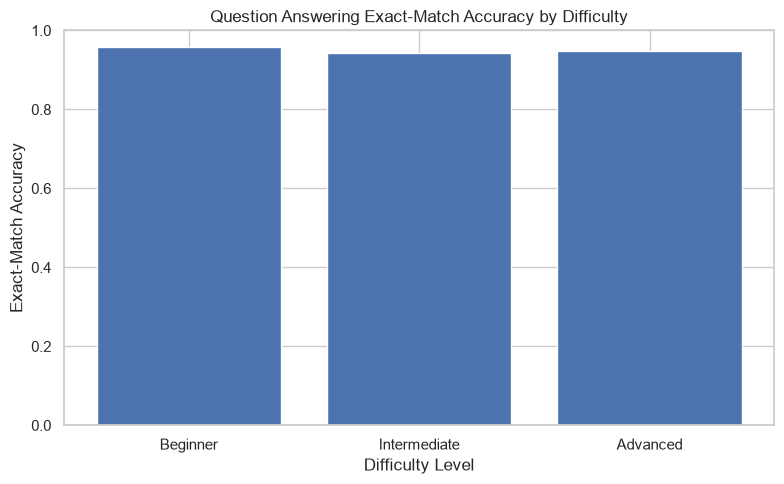

In [126]:
plt.figure(figsize=(8, 5))

plt.bar(
    difficulty_accuracy.index,
    difficulty_accuracy["Exact Match Accuracy"]
)

plt.title(
    "Question Answering Exact-Match Accuracy by Difficulty"
)

plt.xlabel("Difficulty Level")
plt.ylabel("Exact-Match Accuracy")

plt.ylim(0, 1)

plt.tight_layout()
plt.show()

## 11.4 Interpretation

The exact-match accuracy was calculated separately for Beginner, Intermediate, and Advanced questions. The results show how the pretrained question-answering model performs at different difficulty levels.

The accuracy values are compared to determine whether model performance decreases as question difficulty increases. A decrease in accuracy from Beginner to Advanced would suggest that more difficult questions are harder for the pretrained model to answer correctly. If the values do not follow this pattern, then the results do not show a consistent relationship between difficulty and accuracy.

# Part 12: Text Summarization

Text summarization is the process of producing a shorter version of a text while preserving its main information.

In this part, a simple extractive summarization method will first be implemented. The sentence with the highest average TF-IDF score will be selected as the summary for each article.

In [128]:
summarization_path = os.path.join(
    DATA_PATH,
    "text_summarization.csv"
)

summary_df = pd.read_csv(
    summarization_path
)

print("Dataset shape:", summary_df.shape)
print("Columns:", summary_df.columns.tolist())

display(summary_df.head())

Dataset shape: (2000, 5)
Columns: ['id', 'text', 'summary', 'category', 'difficulty']


,id,text,summary,category,difficulty
0,1,Blue Horizon Airlines reported stronger than e...,Blue Horizon Airlines's Amsterdam division pos...,Business,Intermediate
1,2,The latest film from Summit Robotics Inc. brok...,Summit Robotics Inc.'s new film breaks box off...,Entertainment,Intermediate
2,3,"Tourism officials in Osaka, working with Zenit...",Osaka and Zenith Pharmaceuticals launch a camp...,Travel,Beginner
3,4,Harborview College announced a new scholarship...,Harborview College launches a scholarship and ...,Education,Beginner
4,5,Harborview College unveiled a new smartphone t...,Harborview College launches a new smartphone a...,Technology,Advanced


In [132]:
import re
import numpy as np

from sklearn.feature_extraction.text import TfidfVectorizer


def extractive_summary(article):
    
    sentences = re.split(
        r'(?<=[.!?])\s+',
        str(article).strip()
    )
    
    sentences = [
        sentence.strip()
        for sentence in sentences
        if sentence.strip()
    ]
    
    if len(sentences) == 0:
        return ""
    
    if len(sentences) == 1:
        return sentences[0]
    
    vectorizer = TfidfVectorizer(
        stop_words="english"
    )
    
    try:
        tfidf_matrix = vectorizer.fit_transform(
            sentences
        )
        
        average_scores = np.asarray(
            tfidf_matrix.mean(axis=1)
        ).ravel()
        
        best_sentence_index = np.argmax(
            average_scores
        )
        
        return sentences[best_sentence_index]
    
    except ValueError:
        return sentences[0]

In [137]:
print(summary_samples_10.columns.tolist())

['id', 'text', 'summary', 'category', 'difficulty']


In [138]:
summary_samples_10 = summary_df.sample(
    n=10,
    random_state=SEED
).reset_index(drop=True)

summary_results = []

for _, row in summary_samples_10.iterrows():
    
    article = row["text"]
    
    extractive = extractive_summary(
        article
    )
    
    summary_results.append({
        "category": row["category"],
        "extractive_summary": extractive,
        "reference_summary": row["summary"]
    })

summary_results_df = pd.DataFrame(
    summary_results
)

display(summary_results_df)

,category,extractive_summary,reference_summary
0,Health,A new clinic backed by Riverside Bank opened i...,Riverside Bank opens a new clinic in Cairo exp...
1,Entertainment,The latest film from Brightline Technologies b...,Brightline Technologies's new film breaks box ...
2,Travel,A new direct flight route between Seoul and a ...,Union Manufacturing Corp. announces a new dire...
3,Education,Quantum Innovations announced a new scholarshi...,Quantum Innovations launches a scholarship and...
4,Entertainment,The latest film from BrightFuture Foundation b...,BrightFuture Foundation's new film breaks box ...
5,Entertainment,A popular streaming series produced by BrightF...,"BrightFuture Foundation's streaming series, fi..."
6,Business,A merger between Pioneer Research Institute an...,Pioneer Research Institute and a major firm in...
7,Entertainment,A popular streaming series produced by Ironwoo...,"Ironwood Steel Works's streaming series, filme..."
8,Education,Pioneer Research Institute announced a new sch...,Pioneer Research Institute launches a scholars...
9,Entertainment,The latest film from Aurora Data Systems broke...,Aurora Data Systems's new film breaks box offi...


### Q12.1 Interpretation

The extractive baseline selected one sentence from each article based on its average TF-IDF score. This approach identifies sentences containing words that are relatively important within the article.

The generated summaries remain original sentences from the articles, so they preserve the original wording but may not always form the most complete or concise summary. Comparing them with the reference summaries shows how well a simple statistical method can capture the main information.

In [134]:
from transformers import pipeline

summarization_pipeline = pipeline(
    "summarization",
    model="sshleifer/distilbart-cnn-12-6"
)

print("Summarization pipeline loaded successfully.")

Device set to use cpu


Summarization pipeline loaded successfully.


In [145]:
abstractive_summaries = []

for _, row in summary_samples_10.iterrows():
    
    article = str(row["text"])
    
    words = article.split()
    
    if len(words) > 900:
        article = " ".join(words[:900])
    
    result = summarization_pipeline(
        article,
        max_length=80,
        min_length=15,
        do_sample=False
    )
    
    abstractive_summaries.append(
        result[0]["summary_text"]
    )

summary_results_df[
    "abstractive_summary"
] = abstractive_summaries

display(
    summary_results_df[
        [
            "category",
            "extractive_summary",
            "abstractive_summary",
            "reference_summary"
        ]
    ]
)

Your max_length is set to 80, but your input_length is only 48. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer('...', max_length=24)
Your max_length is set to 80, but your input_length is only 46. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer('...', max_length=23)
Your max_length is set to 80, but your input_length is only 48. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer('...', max_length=24)
Your max_length is set to 80, but your input_length is only 49. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer('...', max_length=24)
Your max

,category,extractive_summary,abstractive_summary,reference_summary
0,Health,A new clinic backed by Riverside Bank opened i...,A new clinic backed by Riverside Bank opened ...,Riverside Bank opens a new clinic in Cairo exp...
1,Entertainment,The latest film from Brightline Technologies b...,The latest film from Brightline Technologies ...,Brightline Technologies's new film breaks box ...
2,Travel,A new direct flight route between Seoul and a ...,Union Manufacturing Corp. announced a new dir...,Union Manufacturing Corp. announces a new dire...
3,Education,Quantum Innovations announced a new scholarshi...,Quantum Innovations announced a new scholarsh...,Quantum Innovations launches a scholarship and...
4,Entertainment,The latest film from BrightFuture Foundation b...,The latest film from BrightFuture Foundation ...,BrightFuture Foundation's new film breaks box ...
5,Entertainment,A popular streaming series produced by BrightF...,A popular streaming series produced by Bright...,"BrightFuture Foundation's streaming series, fi..."
6,Business,A merger between Pioneer Research Institute an...,Pioneer Research Institute is expected to clo...,Pioneer Research Institute and a major firm in...
7,Entertainment,A popular streaming series produced by Ironwoo...,A popular streaming series produced by Ironwo...,"Ironwood Steel Works's streaming series, filme..."
8,Education,Pioneer Research Institute announced a new sch...,Pioneer Research Institute announced a new sc...,Pioneer Research Institute launches a scholars...
9,Entertainment,The latest film from Aurora Data Systems broke...,The latest film from Aurora Data Systems brok...,Aurora Data Systems's new film breaks box offi...


### Q12.2 Interpretation

The abstractive model generated summaries for the same 10 articles used in the extractive baseline.

The extractive summaries use sentences directly from the original articles, while the abstractive summaries can rewrite and combine information into new sentences. The reference summaries provide a basis for comparing how well both approaches capture the important information from each article.

The qualitative comparison should focus on whether the generated summary captures the main idea, removes unnecessary details, and remains similar in meaning to the reference summary.

### Q12.3 Interpretation

**Extractive summarization:**  
Extractive summarization selects existing sentences from the original article. Its main advantage is that it is simple and less likely to generate information that was not present in the source. Its disadvantage is that the selected sentence may not form a smooth or complete summary and may contain unnecessary information.

**Abstractive summarization:**  
Abstractive summarization generates new wording based on the information in the article. Its main advantage is that it can produce shorter and more natural summaries that combine important information. Its disadvantage is that a generative model can sometimes leave out important information or produce information that is not completely supported by the original article.

From the results, the extractive method is easier to implement and remains closely connected to the source text, while the abstractive model generally provides more flexible and natural summaries.

In [141]:
summary_df["article_word_count"] = (
    summary_df["text"]
    .astype(str)
    .str.split()
    .str.len()
)

summary_df["summary_word_count"] = (
    summary_df["summary"]
    .astype(str)
    .str.split()
    .str.len()
)

summary_df["compression_ratio"] = (
    summary_df["summary_word_count"]
    / summary_df["article_word_count"]
)

compression_by_category = (
    summary_df
    .groupby("category")["compression_ratio"]
    .agg(["count", "mean"])
    .rename(
        columns={
            "count": "Number of Articles",
            "mean": "Average Compression Ratio"
        }
    )
)

display(
    compression_by_category.style.format({
        "Average Compression Ratio": "{:.4f}"
    })
)

,Number of Articles,Average Compression Ratio
category,,
Business,250,0.3557
Education,250,0.3352
Entertainment,250,0.3745
Health,250,0.3506
Science,250,0.3206
Sports,250,0.3390
Technology,250,0.3082
Travel,250,0.3580


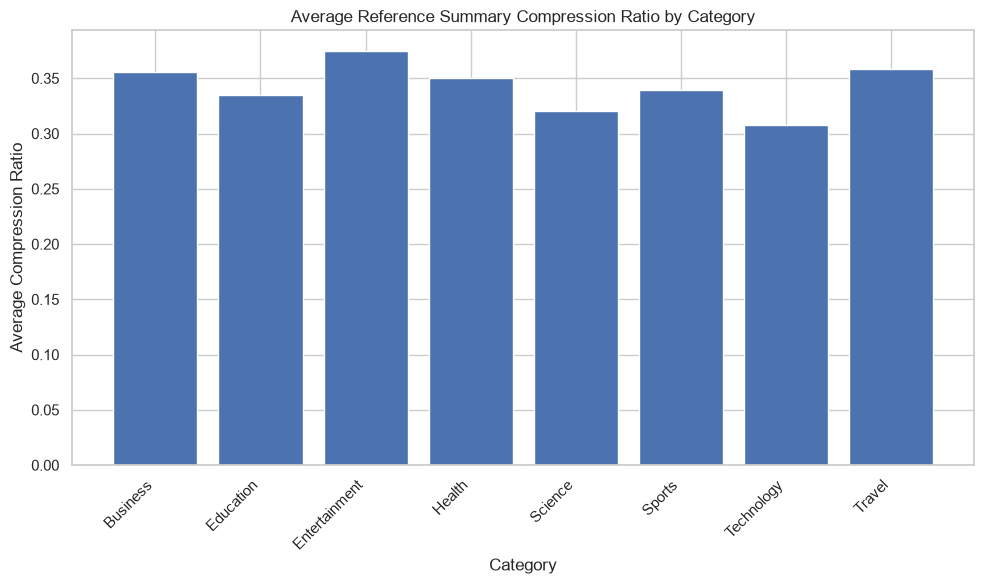

In [142]:
plt.figure(figsize=(10, 6))

plt.bar(
    compression_by_category.index,
    compression_by_category[
        "Average Compression Ratio"
    ]
)

plt.title(
    "Average Reference Summary Compression Ratio by Category"
)

plt.xlabel("Category")
plt.ylabel("Average Compression Ratio")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

### Q12.4 Interpretation

The average compression ratio was calculated for each article category. A lower compression ratio means that the reference summaries are much shorter compared with their original articles, while a higher ratio means that the summaries retain a larger proportion of the original text.

The compression ratios are not necessarily identical across all categories. Variation can occur because different topics may contain different amounts of information, sentence structures, or levels of detail. Some categories may require longer summaries to preserve their main information, while others can be summarized more aggressively.

# Part 13